# Раздельный анализ когерентности ЭЭГ и POLY-сигналов

Ноутбук сначала проверяет алгоритм на внешнем Kaggle-датасете по ожидаемым ЭЭГ-закономерностям, а затем анализирует основной эксперимент из папки `data`.

Основной анализ разделён на уровни:

1. **Базовый уровень** — минимальная предобработка, корреляция и обычная coherence. Он показывает, есть ли сходство сигналов вообще.
2. **Артефакт-контроль** — предобработка как в Data Studio и разделение результатов на `all`, `clean`, `weighted`. Он показывает, не объясняется ли связь POLY/ЭМГ-помехами.
3. **Проверка без подозрительного POLY-канала** — тот же расчёт, но с исключением каналов, которые могут вести себя как дубли/аппаратные артефакты.
4. **Фазовая проверка** — более строгие метрики `imaginary coherence`, `PLI`, `WPLI`. Этот уровень нужен для осторожной физиологической интерпретации.

Ключевые настройки сравниваемых каналов остаются в начале ноутбука в `CFG.groups` и `CFG.comparison_plan`.

In [33]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Iterable

import copy
import subprocess
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import signal


Здесь подключаются библиотеки для чтения CSV, фильтрации сигналов, расчёта спектральных показателей, построения графиков и сохранения результатов.

In [34]:
@dataclass
class AnalysisConfig:
    """Параметры анализа, которые обычно меняются между экспериментами."""

    data_dir: Path = Path("data")
    csv_glob: str = "*.csv"
    output_dir: Path = Path("analysis_results_data_experiment")
    max_files: int | None = None

    fs_hz: float = 500.0
    high_pass_hz: float | None = 0.53
    low_pass_hz: float | None = 30.0
    notch_hz: float | None = 50.0
    apply_filters: bool = True

    window_sec: float = 4.0
    step_sec: float = 1.0
    max_lag_sec: float = 0.2
    welch_segment_sec: float = 2.0

    csv_separator: str | None = None
    no_header_channel_names: list[str] | None = None
    event_column_candidates: tuple[str, ...] = (
        "event",
        "event_text",
        "condition",
        "marker",
        "annotation",
    )

    groups: dict[str, list[str]] = field(
        default_factory=lambda: {
            "occipital_eeg": ["O1", "O2"],
            "frontal_eeg": ["Fp1", "Fp2"],
            "ears_reference_sensitive": ["A1", "A2"],
            "neck_poly_bipolar": ["POLY3", "POLY4"],
        }
    )
    comparison_plan: list[tuple[str, str]] = field(
        default_factory=lambda: [
            ("occipital_eeg", "neck_poly_bipolar"),
            ("frontal_eeg", "neck_poly_bipolar"),
            ("ears_reference_sensitive", "neck_poly_bipolar"),
            ("occipital_eeg", "occipital_eeg"),
            ("frontal_eeg", "frontal_eeg"),
            ("ears_reference_sensitive", "ears_reference_sensitive"),
            ("neck_poly_bipolar", "neck_poly_bipolar"),
        ]
    )
    channel_roles: dict[str, str] = field(
        default_factory=lambda: {
            "Fp1": "EEG_FRONTAL_LEFT_REFERENCE_AV",
            "Fp2": "EEG_FRONTAL_RIGHT_REFERENCE_AV",
            "O1": "EEG_OCCIPITAL_LEFT_REFERENCE_AV",
            "O2": "EEG_OCCIPITAL_RIGHT_REFERENCE_AV",
            "A1": "EAR_CHANNEL_REFERENCE_SENSITIVE",
            "A2": "EAR_CHANNEL_REFERENCE_SENSITIVE",
            "POLY3": "POLY_BIPOLAR_LOCAL_NECK_EMG_SENSITIVE",
            "POLY4": "POLY_BIPOLAR_LOCAL_NECK_EMG_SENSITIVE",
        }
    )
    poly_channels: list[str] = field(default_factory=lambda: ["POLY3", "POLY4"])

    frequency_bands: dict[str, tuple[float, float]] = field(
        default_factory=lambda: {
            "delta": (1.0, 4.0),
            "theta": (4.0, 8.0),
            "alpha": (8.0, 13.0),
            "beta1": (13.0, 20.0),
            "beta2_emg_sensitive": (20.0, 30.0),
        }
    )

    artifact_band_hz: tuple[float, float] = (20.0, 30.0)
    artifact_score_threshold: float = 3.0
    artifact_weight_floor: float = 0.25

    compute_phase_metrics: bool = True
    phase_metric_bands: tuple[str, ...] = ("alpha", "beta2_emg_sensitive")

    show_progress: bool = True


CFG = AnalysisConfig()
CFG.output_dir.mkdir(parents=True, exist_ok=True)

print("Папка с исходными CSV:", CFG.data_dir.resolve())
print("Шаблон CSV:", CFG.csv_glob)
print("Папка результатов:", CFG.output_dir.resolve())
print("Группы каналов:", CFG.groups)
print("План сравнений:", CFG.comparison_plan)
print("Фазовые метрики считаются для полос:", CFG.phase_metric_bands)


Папка с исходными CSV: C:\Users\chuma\Documents\диплом\программа\data
Шаблон CSV: *.csv
Папка результатов: C:\Users\chuma\Documents\диплом\программа\analysis_results_data_experiment
Группы каналов: {'occipital_eeg': ['O1', 'O2'], 'frontal_eeg': ['Fp1', 'Fp2'], 'ears_reference_sensitive': ['A1', 'A2'], 'neck_poly_bipolar': ['POLY3', 'POLY4']}
План сравнений: [('occipital_eeg', 'neck_poly_bipolar'), ('frontal_eeg', 'neck_poly_bipolar'), ('ears_reference_sensitive', 'neck_poly_bipolar'), ('occipital_eeg', 'occipital_eeg'), ('frontal_eeg', 'frontal_eeg'), ('ears_reference_sensitive', 'ears_reference_sensitive'), ('neck_poly_bipolar', 'neck_poly_bipolar')]
Фазовые метрики считаются для полос: ('alpha', 'beta2_emg_sensitive')


В этой ячейке задаётся универсальная конфигурация. Для другого эксперимента обычно достаточно изменить `groups`, `comparison_plan`, частоту дискретизации и папку с CSV.

## Вспомогательные функции чтения CSV

Файлы Data Studio и внешние CSV могут отличаться кодировкой, разделителем и наличием заголовка. Поэтому чтение сделано с несколькими проверками.

In [35]:
def _looks_like_numeric_header(columns: Iterable[Any]) -> bool:
    """Проверяет, похожи ли имена колонок на случайно прочитанную строку данных."""
    columns = list(columns)
    if not columns:
        return False

    numeric_like = 0
    for value in columns:
        try:
            float(str(value).replace(",", "."))
            numeric_like += 1
        except ValueError:
            continue

    return numeric_like / len(columns) > 0.7


def _read_csv_flexible(
    path: Path,
    separator: str | None = None,
    no_header_channel_names: list[str] | None = None,
) -> pd.DataFrame:
    """Читает CSV с автоопределением кодировки, разделителя и заголовка."""
    encodings = ("utf-8-sig", "utf-8", "cp1251", "latin1")
    last_error: Exception | None = None

    for encoding in encodings:
        try:
            dataframe = pd.read_csv(
                path,
                sep=separator,
                engine="python",
                encoding=encoding,
            )

            if _looks_like_numeric_header(dataframe.columns):
                dataframe = pd.read_csv(
                    path,
                    sep=separator,
                    engine="python",
                    encoding=encoding,
                    header=None,
                )

            break
        except Exception as error:  # noqa: BLE001
            last_error = error
    else:
        raise RuntimeError(f"Не удалось прочитать {path}: {last_error}")

    if no_header_channel_names is not None:
        if dataframe.shape[1] >= len(no_header_channel_names):
            renamed = list(no_header_channel_names)
            tail_count = dataframe.shape[1] - len(no_header_channel_names)
            renamed.extend([f"extra_{index}" for index in range(tail_count)])
            dataframe.columns = renamed

    dataframe.columns = [str(column).strip() for column in dataframe.columns]
    return dataframe


def _first_existing_column(
    columns: Iterable[str],
    candidates: Iterable[str],
) -> str | None:
    """Возвращает имя первой найденной колонки без учёта регистра."""
    lower_to_original = {str(column).lower(): str(column) for column in columns}
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    return None


def read_eeg_csv(path: Path, config: AnalysisConfig) -> tuple[pd.DataFrame, str]:
    """Возвращает числовую таблицу каналов и текст события."""
    raw = _read_csv_flexible(
        path=path,
        separator=config.csv_separator,
        no_header_channel_names=config.no_header_channel_names,
    )

    event_column = _first_existing_column(raw.columns, config.event_column_candidates)
    event_text = path.stem
    if event_column is not None:
        values = raw[event_column].dropna().astype(str)
        values = values[values.str.strip() != ""]
        if len(values) > 0:
            event_text = values.iloc[0]

    requested_channels = set()
    for channels in config.groups.values():
        requested_channels.update(channels)
    requested_channels.update(config.poly_channels)

    numeric = pd.DataFrame(index=raw.index)
    for column in raw.columns:
        if column not in requested_channels:
            continue
        numeric[column] = pd.to_numeric(raw[column], errors="coerce")

    numeric = numeric.dropna(how="all")
    numeric = numeric.interpolate(limit_direction="both").dropna(axis=1, how="all")

    if numeric.empty:
        raise ValueError(
            f"В файле {path.name} не найдены заданные каналы. "
            f"Доступные колонки: {list(raw.columns)[:30]}"
        )

    return numeric, event_text

Эти функции превращают CSV в числовую таблицу только тех каналов, которые указаны в конфигурации. Если файл без заголовков, можно заранее передать порядок каналов через `no_header_channel_names`.

## Предобработка сигналов

Фильтрация оставлена настраиваемой. Для файлов, уже прошедших предобработку в Data Studio, параметры можно сохранить такими же, как в экспорте, либо отключить повторную фильтрацию через `apply_filters = False`.

In [36]:
def _safe_sos_filter(
    data: np.ndarray,
    sos: np.ndarray,
) -> np.ndarray:
    """Применяет zero-phase фильтр, если длина сигнала достаточна."""
    if len(data) < max(32, 3 * sos.shape[0] * 2):
        return data
    return signal.sosfiltfilt(sos, data)


def preprocess_channel(values: np.ndarray, config: AnalysisConfig) -> np.ndarray:
    """Удаляет тренд и применяет выбранные фильтры."""
    x = np.asarray(values, dtype=float)
    x = pd.Series(x).interpolate(limit_direction="both").to_numpy()
    x = signal.detrend(x, type="linear")

    if not config.apply_filters:
        return x

    nyquist = config.fs_hz / 2.0
    low = config.high_pass_hz
    high = config.low_pass_hz

    if low is not None and high is not None and 0 < low < high < nyquist:
        sos = signal.butter(
            4,
            [low / nyquist, high / nyquist],
            btype="bandpass",
            output="sos",
        )
        x = _safe_sos_filter(x, sos)
    elif low is not None and 0 < low < nyquist:
        sos = signal.butter(4, low / nyquist, btype="highpass", output="sos")
        x = _safe_sos_filter(x, sos)
    elif high is not None and 0 < high < nyquist:
        sos = signal.butter(4, high / nyquist, btype="lowpass", output="sos")
        x = _safe_sos_filter(x, sos)

    if config.notch_hz is not None and config.notch_hz < nyquist:
        b_coeff, a_coeff = signal.iirnotch(
            w0=config.notch_hz,
            Q=30.0,
            fs=config.fs_hz,
        )
        if len(x) > 3 * max(len(a_coeff), len(b_coeff)):
            x = signal.filtfilt(b_coeff, a_coeff, x)

    return x


def preprocess_dataframe(
    dataframe: pd.DataFrame,
    config: AnalysisConfig,
) -> pd.DataFrame:
    """Предобрабатывает все числовые каналы в файле."""
    output = pd.DataFrame(index=dataframe.index)
    for column in dataframe.columns:
        output[column] = preprocess_channel(dataframe[column].to_numpy(), config)
    return output

Здесь реализована базовая предобработка: интерполяция пропусков, удаление тренда, полосовая фильтрация и notch-фильтр при необходимости.

## Окна, пары каналов и тип сравнения

Сигнал анализируется короткими перекрывающимися окнами. Это позволяет сравнивать условия и отдельно исключать окна с выраженной POLY/ЭМГ-помехой.

In [37]:
def iter_windows(
    n_samples: int,
    config: AnalysisConfig,
) -> Iterable[tuple[int, int, float, float]]:
    """Генерирует индексы окон и их границы в секундах."""
    window_size = int(round(config.window_sec * config.fs_hz))
    step_size = int(round(config.step_sec * config.fs_hz))

    if window_size <= 1 or step_size <= 0 or n_samples < window_size:
        return

    for start in range(0, n_samples - window_size + 1, step_size):
        end = start + window_size
        yield start, end, start / config.fs_hz, end / config.fs_hz


def build_channel_pairs(config: AnalysisConfig) -> list[dict[str, str]]:
    """Строит список пар каналов из групп, заданных в comparison_plan."""
    rows: list[dict[str, str]] = []

    for left_group, right_group in config.comparison_plan:
        left_channels = config.groups.get(left_group, [])
        right_channels = config.groups.get(right_group, [])

        for left_channel in left_channels:
            for right_channel in right_channels:
                if left_channel == right_channel:
                    continue
                if left_group == right_group and left_channel > right_channel:
                    continue

                left_role = config.channel_roles.get(left_channel, "UNKNOWN")
                right_role = config.channel_roles.get(right_channel, "UNKNOWN")

                if "POLY" in left_role or "POLY" in right_role:
                    relation_type = "EEG_POLY_SPECTRAL_SIMILARITY"
                    if "POLY" in left_role and "POLY" in right_role:
                        relation_type = "POLY_POLY_LOCAL_NECK_SIMILARITY"
                else:
                    relation_type = "EEG_EEG_CONNECTIVITY"

                rows.append(
                    {
                        "left_group": left_group,
                        "right_group": right_group,
                        "comparison": f"{left_group}__vs__{right_group}",
                        "left_channel": left_channel,
                        "right_channel": right_channel,
                        "pair": f"{left_channel}-{right_channel}",
                        "relation_type": relation_type,
                    }
                )

    return rows


CHANNEL_PAIRS = build_channel_pairs(CFG)
pd.DataFrame(CHANNEL_PAIRS).head(10)

,left_group,right_group,comparison,left_channel,right_channel,pair,relation_type
0,occipital_eeg,neck_poly_bipolar,occipital_eeg__vs__neck_poly_bipolar,O1,POLY3,O1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY
1,occipital_eeg,neck_poly_bipolar,occipital_eeg__vs__neck_poly_bipolar,O1,POLY4,O1-POLY4,EEG_POLY_SPECTRAL_SIMILARITY
2,occipital_eeg,neck_poly_bipolar,occipital_eeg__vs__neck_poly_bipolar,O2,POLY3,O2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY
3,occipital_eeg,neck_poly_bipolar,occipital_eeg__vs__neck_poly_bipolar,O2,POLY4,O2-POLY4,EEG_POLY_SPECTRAL_SIMILARITY
4,frontal_eeg,neck_poly_bipolar,frontal_eeg__vs__neck_poly_bipolar,Fp1,POLY3,Fp1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY
5,frontal_eeg,neck_poly_bipolar,frontal_eeg__vs__neck_poly_bipolar,Fp1,POLY4,Fp1-POLY4,EEG_POLY_SPECTRAL_SIMILARITY
6,frontal_eeg,neck_poly_bipolar,frontal_eeg__vs__neck_poly_bipolar,Fp2,POLY3,Fp2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY
7,frontal_eeg,neck_poly_bipolar,frontal_eeg__vs__neck_poly_bipolar,Fp2,POLY4,Fp2-POLY4,EEG_POLY_SPECTRAL_SIMILARITY
8,ears_reference_sensitive,neck_poly_bipolar,ears_reference_sensitive__vs__neck_poly_bipolar,A1,POLY3,A1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY
9,ears_reference_sensitive,neck_poly_bipolar,ears_reference_sensitive__vs__neck_poly_bipolar,A1,POLY4,A1-POLY4,EEG_POLY_SPECTRAL_SIMILARITY


Эта ячейка показывает первые пары, которые будут анализироваться. Если в начале ноутбука поменять `groups` или `comparison_plan`, список пар перестроится автоматически.

## Метрики временного и спектрального сходства

Обычная когерентность показывает спектральное сходство. `imaginary coherence`, `PLI` и `WPLI` добавлены как более осторожные фазовые показатели, менее чувствительные к нулевому фазовому компоненту.

In [38]:
def robust_z_score(values: pd.Series | np.ndarray) -> np.ndarray:
    """Робастная z-оценка через медиану и MAD."""
    array = np.asarray(values, dtype=float)
    median = np.nanmedian(array)
    mad = np.nanmedian(np.abs(array - median))
    if not np.isfinite(mad) or mad == 0:
        return np.zeros_like(array, dtype=float)
    return 0.6745 * (array - median) / mad


def safe_corrcoef(x: np.ndarray, y: np.ndarray) -> float:
    """Корреляция Пирсона с защитой от констант и пропусков."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan

    x = x[mask]
    y = y[mask]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def lagged_correlation(
    x: np.ndarray,
    y: np.ndarray,
    config: AnalysisConfig,
) -> tuple[float, float]:
    """Быстрая оценка максимальной корреляции при небольшом лаге."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 8:
        return np.nan, 0.0

    x = x[mask]
    y = y[mask]
    if len(x) != len(y):
        length = min(len(x), len(y))
        x = x[:length]
        y = y[:length]

    x = x - np.mean(x)
    y = y - np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    if x_std == 0 or y_std == 0:
        return np.nan, 0.0

    max_lag = int(round(config.max_lag_sec * config.fs_hz))
    max_lag = min(max_lag, len(x) - 2)
    if max_lag <= 0:
        return safe_corrcoef(x, y), 0.0

    corr_full = signal.correlate(x, y, mode="full", method="auto")
    lags = signal.correlation_lags(len(x), len(y), mode="full")
    overlap = len(x) - np.abs(lags)

    valid = (np.abs(lags) <= max_lag) & (overlap > max(8, len(x) // 4))
    if not np.any(valid):
        return np.nan, 0.0

    corr_values = corr_full[valid] / (x_std * y_std * overlap[valid])
    corr_values = np.clip(corr_values, -1.0, 1.0)
    lag_values = lags[valid]

    best_index = int(np.nanargmax(np.abs(corr_values)))
    best_corr = float(corr_values[best_index])
    best_lag = float(lag_values[best_index] / config.fs_hz)
    return best_corr, best_lag


def _welch_nperseg(length: int, config: AnalysisConfig) -> int:
    """Подбирает длину сегмента Welch под текущее окно."""
    desired = int(round(config.welch_segment_sec * config.fs_hz))
    return max(16, min(length, desired))


def bandpass_for_phase(
    x: np.ndarray,
    band: tuple[float, float],
    fs_hz: float,
) -> np.ndarray | None:
    """Фильтр для фазовых метрик внутри конкретной полосы."""
    low, high = band
    nyquist = fs_hz / 2.0
    if not (0 < low < high < nyquist):
        return None

    sos = signal.butter(
        3,
        [low / nyquist, high / nyquist],
        btype="bandpass",
        output="sos",
    )
    return _safe_sos_filter(x, sos)


def phase_metrics(
    x: np.ndarray,
    y: np.ndarray,
    band: tuple[float, float],
    fs_hz: float,
) -> dict[str, float]:
    """Считает PLV, PLI и WPLI по аналитическому сигналу."""
    x_band = bandpass_for_phase(x, band, fs_hz)
    y_band = bandpass_for_phase(y, band, fs_hz)
    if x_band is None or y_band is None:
        return {"plv": np.nan, "pli": np.nan, "wpli": np.nan}

    x_analytic = signal.hilbert(x_band)
    y_analytic = signal.hilbert(y_band)
    phase_diff = np.angle(x_analytic) - np.angle(y_analytic)

    plv = np.abs(np.mean(np.exp(1j * phase_diff)))
    pli = np.abs(np.mean(np.sign(np.sin(phase_diff))))

    cross_imag = np.imag(x_analytic * np.conj(y_analytic))
    denominator = np.mean(np.abs(cross_imag))
    wpli = np.nan if denominator == 0 else np.abs(np.mean(cross_imag)) / denominator

    return {"plv": float(plv), "pli": float(pli), "wpli": float(wpli)}


def spectral_metrics(
    x: np.ndarray,
    y: np.ndarray,
    config: AnalysisConfig,
) -> dict[str, float]:
    """Считает coherence, imaginary coherence и фазовые метрики."""
    nperseg = _welch_nperseg(len(x), config)
    noverlap = nperseg // 2

    freqs, coherence_values = signal.coherence(
        x,
        y,
        fs=config.fs_hz,
        nperseg=nperseg,
        noverlap=noverlap,
    )
    _, pxx = signal.welch(x, fs=config.fs_hz, nperseg=nperseg, noverlap=noverlap)
    _, pyy = signal.welch(y, fs=config.fs_hz, nperseg=nperseg, noverlap=noverlap)
    _, pxy = signal.csd(x, y, fs=config.fs_hz, nperseg=nperseg, noverlap=noverlap)

    with np.errstate(divide="ignore", invalid="ignore"):
        coherency = pxy / np.sqrt(pxx * pyy)

    results: dict[str, float] = {}

    for band_name, band in config.frequency_bands.items():
        low, high = band
        mask = (freqs >= low) & (freqs < high)

        if not np.any(mask):
            results[f"{band_name}_coherence"] = np.nan
            results[f"{band_name}_imag_coherence"] = np.nan
            results[f"{band_name}_plv"] = np.nan
            results[f"{band_name}_pli"] = np.nan
            results[f"{band_name}_wpli"] = np.nan
            continue

        results[f"{band_name}_coherence"] = float(np.nanmean(coherence_values[mask]))
        results[f"{band_name}_imag_coherence"] = float(
            np.nanmean(np.abs(np.imag(coherency[mask])))
        )

        if config.compute_phase_metrics and band_name in config.phase_metric_bands:
            phase = phase_metrics(x, y, band, config.fs_hz)
            results[f"{band_name}_plv"] = phase["plv"]
            results[f"{band_name}_pli"] = phase["pli"]
            results[f"{band_name}_wpli"] = phase["wpli"]
        else:
            results[f"{band_name}_plv"] = np.nan
            results[f"{band_name}_pli"] = np.nan
            results[f"{band_name}_wpli"] = np.nan

    return results


def pair_metrics(
    x: np.ndarray,
    y: np.ndarray,
    config: AnalysisConfig,
) -> dict[str, float]:
    """Объединяет временные и спектральные показатели для пары каналов."""
    corr = safe_corrcoef(x, y)
    lag_corr, best_lag = lagged_correlation(x, y, config)
    metrics = {
        "time_corr_r": corr,
        "abs_time_corr_r": abs(corr) if np.isfinite(corr) else np.nan,
        "max_lag_corr_r": lag_corr,
        "abs_max_lag_corr_r": abs(lag_corr) if np.isfinite(lag_corr) else np.nan,
        "best_lag_sec": best_lag,
    }
    metrics.update(spectral_metrics(x, y, config))
    return metrics


Эта часть считает основные показатели для каждой пары: корреляцию, корреляцию с лагом, когерентность и фазовые метрики по частотным диапазонам.

## Оценка мышечной активности в биполярных POLY-каналах

Для `POLY3/POLY4` используются признаки, характерные для локальной мышечной/полиграфической активности: RMS, line length и доля мощности в диапазоне `20-30 Гц`. Если POLY-каналов нет, блок автоматически возвращает нейтральные веса.

In [39]:
def band_power_ratio(
    x: np.ndarray,
    config: AnalysisConfig,
    band: tuple[float, float],
) -> float:
    """Доля мощности выбранной полосы относительно мощности 1-30 Гц."""
    nperseg = _welch_nperseg(len(x), config)
    freqs, power = signal.welch(x, fs=config.fs_hz, nperseg=nperseg)

    total_mask = (freqs >= 1.0) & (freqs <= min(30.0, config.fs_hz / 2.0 - 1e-9))
    band_mask = (freqs >= band[0]) & (freqs < min(band[1], config.fs_hz / 2.0))

    total_power = np.trapezoid(power[total_mask], freqs[total_mask])
    band_power = np.trapezoid(power[band_mask], freqs[band_mask])

    if total_power <= 0 or not np.isfinite(total_power):
        return np.nan
    return float(band_power / total_power)


def poly_artifact_metrics_for_window(
    dataframe: pd.DataFrame,
    start: int,
    end: int,
    config: AnalysisConfig,
) -> list[dict[str, float | str]]:
    """Считает признаки POLY/ЭМГ-помехи по каждому доступному POLY-каналу."""
    rows: list[dict[str, float | str]] = []
    for channel in config.poly_channels:
        if channel not in dataframe.columns:
            continue

        x = dataframe[channel].iloc[start:end].to_numpy(dtype=float)
        rows.append(
            {
                "channel": channel,
                "rms": float(np.sqrt(np.mean(x**2))),
                "line_length": float(np.mean(np.abs(np.diff(x)))),
                "hf_ratio_20_30": band_power_ratio(
                    x,
                    config=config,
                    band=config.artifact_band_hz,
                ),
            }
        )
    return rows


def summarize_artifacts(
    artifact_detail: pd.DataFrame,
    config: AnalysisConfig,
) -> pd.DataFrame:
    """Агрегирует POLY-признаки до одного веса окна."""
    output_columns = [
        "file",
        "event",
        "event_group",
        "window_start_sec",
        "window_end_sec",
        "poly_artifact_score",
        "poly_rms",
        "poly_line_length",
        "poly_hf_ratio_20_30",
        "poly_artifact_flag",
        "artifact_weight",
    ]

    if artifact_detail.empty:
        return pd.DataFrame(columns=output_columns)

    detail = artifact_detail.copy()
    for metric in ("rms", "line_length", "hf_ratio_20_30"):
        detail[f"{metric}_rz"] = robust_z_score(detail[metric])

    detail["artifact_score"] = detail[
        ["rms_rz", "line_length_rz", "hf_ratio_20_30_rz"]
    ].max(axis=1)

    grouped = detail.groupby(
        ["file", "event", "event_group", "window_start_sec", "window_end_sec"],
        as_index=False,
    )
    aggregated = grouped.agg(
        poly_artifact_score=("artifact_score", "max"),
        poly_rms=("rms", "mean"),
        poly_line_length=("line_length", "mean"),
        poly_hf_ratio_20_30=("hf_ratio_20_30", "mean"),
    )

    aggregated["poly_artifact_flag"] = (
        aggregated["poly_artifact_score"] >= config.artifact_score_threshold
    )
    aggregated["artifact_weight"] = 1.0 / (1.0 + aggregated["poly_artifact_score"])
    aggregated["artifact_weight"] = aggregated["artifact_weight"].clip(
        lower=config.artifact_weight_floor,
        upper=1.0,
    )
    return aggregated[output_columns]

Здесь вычисляется показатель мышечной/полиграфической помехи для окон с POLY-каналами. Для обычных ЭЭГ-датасетов без POLY этот блок не мешает анализу.

## Запуск анализа по всем CSV

Каждый CSV читается, предобрабатывается, разбивается на окна, после чего для всех заданных пар каналов считаются метрики.

In [40]:
def normalize_event_group(event_text: str) -> str:
    """Упрощает подпись события для группировки."""
    text = str(event_text).lower()
    if "закры" in text or "closed" in text:
        return "eyes_closed"
    if "откры" in text or "open" in text:
        return "eyes_open"
    if "рук" in text or "hand" in text or "motor" in text:
        return "movement"
    if "kaggle" in text:
        return "kaggle_external"
    return "unknown"


def find_csv_files(config: AnalysisConfig) -> list[Path]:
    """Находит CSV по настройкам конфигурации."""
    files = sorted(config.data_dir.glob(config.csv_glob))
    if config.max_files is not None:
        files = files[: config.max_files]
    if not files:
        raise FileNotFoundError(f"CSV не найдены: {config.data_dir / config.csv_glob}")
    return files


def analyze_file(
    path: Path,
    config: AnalysisConfig,
    channel_pairs: list[dict[str, str]],
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    """Анализирует один CSV-файл."""
    raw, event_text = read_eeg_csv(path, config)
    data = preprocess_dataframe(raw, config)
    event_group = normalize_event_group(event_text)

    metric_rows: list[dict[str, Any]] = []
    artifact_rows: list[dict[str, Any]] = []

    available_pairs = [
        pair
        for pair in channel_pairs
        if pair["left_channel"] in data.columns and pair["right_channel"] in data.columns
    ]

    for start, end, window_start, window_end in iter_windows(len(data), config):
        artifacts = poly_artifact_metrics_for_window(data, start, end, config)
        for artifact in artifacts:
            artifact_rows.append(
                {
                    "file": path.name,
                    "event": event_text,
                    "event_group": event_group,
                    "window_start_sec": window_start,
                    "window_end_sec": window_end,
                    **artifact,
                }
            )

        for pair in available_pairs:
            x = data[pair["left_channel"]].iloc[start:end].to_numpy(dtype=float)
            y = data[pair["right_channel"]].iloc[start:end].to_numpy(dtype=float)
            row = {
                "file": path.name,
                "event": event_text,
                "event_group": event_group,
                "window_start_sec": window_start,
                "window_end_sec": window_end,
                **pair,
                **pair_metrics(x, y, config),
            }
            metric_rows.append(row)

    metadata = {
        "file": path.name,
        "event": event_text,
        "event_group": event_group,
        "duration_sec": len(data) / config.fs_hz,
        "samples": len(data),
        "channels": list(data.columns),
        "pairs_used": len(available_pairs),
    }

    return pd.DataFrame(metric_rows), pd.DataFrame(artifact_rows), metadata


def attach_artifact_weights(
    metrics: pd.DataFrame,
    artifacts: pd.DataFrame,
    config: AnalysisConfig,
) -> pd.DataFrame:
    """Добавляет к таблице метрик веса окон по POLY-помехе."""
    artifact_summary = summarize_artifacts(artifacts, config)
    output = metrics.copy()

    if artifact_summary.empty:
        output["poly_artifact_score"] = 0.0
        output["poly_rms"] = np.nan
        output["poly_line_length"] = np.nan
        output["poly_hf_ratio_20_30"] = np.nan
        output["poly_artifact_flag"] = False
        output["artifact_weight"] = 1.0
        return output

    keys = ["file", "event", "event_group", "window_start_sec", "window_end_sec"]
    output = output.merge(artifact_summary, on=keys, how="left")
    output["poly_artifact_score"] = output["poly_artifact_score"].fillna(0.0)
    output["poly_artifact_flag"] = output["poly_artifact_flag"].fillna(False)
    output["artifact_weight"] = output["artifact_weight"].fillna(1.0)
    return output


def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    """Среднее с весами и защитой от пустых значений."""
    mask = values.notna() & weights.notna()
    if not mask.any():
        return np.nan
    return float(np.average(values[mask], weights=weights[mask]))

Функции этого блока отвечают за полный проход по файлам: поиск CSV, анализ одного файла и присоединение весов, связанных с POLY-помехой.

## Сводные таблицы

В итогах сохраняются три варианта: `all` — все окна, `clean` — без выраженной POLY-помехи, `weighted` — шумные окна учитываются с меньшим весом.

In [41]:
def summarize_pairs(metrics: pd.DataFrame, config: AnalysisConfig) -> pd.DataFrame:
    """Строит сводку по парам каналов."""
    if metrics.empty:
        return pd.DataFrame()

    metric_columns = ["abs_time_corr_r", "abs_max_lag_corr_r"]
    for band_name in config.frequency_bands:
        metric_columns.extend(
            [
                f"{band_name}_coherence",
                f"{band_name}_imag_coherence",
                f"{band_name}_plv",
                f"{band_name}_pli",
                f"{band_name}_wpli",
            ]
        )
    metric_columns = [column for column in metric_columns if column in metrics.columns]

    group_columns = ["comparison", "pair", "relation_type"]
    rows: list[dict[str, Any]] = []

    for keys, group in metrics.groupby(group_columns, dropna=False):
        key_data = dict(zip(group_columns, keys))
        row: dict[str, Any] = {**key_data, "n_windows_all": len(group)}

        clean = group[~group["poly_artifact_flag"]]
        row["n_windows_clean"] = len(clean)
        row["artifact_rate"] = float(group["poly_artifact_flag"].mean())

        for column in metric_columns:
            row[f"all_{column}"] = float(group[column].mean())
            row[f"clean_{column}"] = float(clean[column].mean()) if len(clean) else np.nan
            row[f"weighted_{column}"] = weighted_mean(group[column], group["artifact_weight"])

        rows.append(row)

    summary = pd.DataFrame(rows)
    sort_columns = [
        column
        for column in ["comparison", "clean_alpha_coherence", "clean_abs_time_corr_r"]
        if column in summary.columns
    ]
    ascending = [True, False, False][: len(sort_columns)]
    return summary.sort_values(
        by=sort_columns,
        ascending=ascending,
    ).reset_index(drop=True)


def summarize_by_event(metrics: pd.DataFrame) -> pd.DataFrame:
    """Сводка по типам событий и сравнениям."""
    if metrics.empty:
        return pd.DataFrame()

    columns = [
        "event_group",
        "comparison",
        "relation_type",
        "abs_time_corr_r",
        "alpha_coherence",
        "alpha_wpli",
        "beta2_emg_sensitive_coherence",
        "poly_artifact_flag",
    ]
    columns = [column for column in columns if column in metrics.columns]

    grouped = metrics[columns].groupby(
        ["event_group", "comparison", "relation_type"],
        as_index=False,
    )
    return grouped.agg(
        n_windows=("abs_time_corr_r", "size"),
        artifact_rate=("poly_artifact_flag", "mean"),
        mean_abs_corr=("abs_time_corr_r", "mean"),
        mean_alpha_coherence=("alpha_coherence", "mean"),
        mean_alpha_wpli=("alpha_wpli", "mean"),
        mean_beta2_coherence=("beta2_emg_sensitive_coherence", "mean"),
    )


def compact_pair_table(pair_summary: pd.DataFrame) -> pd.DataFrame:
    """Оставляет только столбцы, полезные для первичной интерпретации."""
    columns = [
        "comparison",
        "pair",
        "relation_type",
        "n_windows_clean",
        "artifact_rate",
        "clean_abs_time_corr_r",
        "clean_alpha_coherence",
        "clean_alpha_imag_coherence",
        "clean_alpha_wpli",
        "clean_beta2_emg_sensitive_coherence",
        "clean_beta2_emg_sensitive_wpli",
    ]
    columns = [column for column in columns if column in pair_summary.columns]
    output = pair_summary[columns].copy()
    numeric_columns = output.select_dtypes(include=[np.number]).columns
    output[numeric_columns] = output[numeric_columns].round(3)
    return output


Эти функции делают небольшие итоговые таблицы. Они не показывают все рассчитанные показатели, а оставляют только те, по которым удобнее делать выводы.

## Графики и сохранение результатов

Графики ограничены несколькими сводными визуализациями: когерентность по группам, WPLI по группам, сравнение обычной и фазовой метрики, доля POLY-помех и эффект очистки окон.

In [42]:
def _save_current_figure(output_dir: Path, filename: str) -> Path:
    """Сохраняет текущий график и возвращает путь."""
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    return path


def plot_heatmap(
    table: pd.DataFrame,
    row_col: str,
    col_col: str,
    value_col: str,
    title: str,
    output_path: Path | None = None,
) -> None:
    """Рисует простую heatmap без внешних библиотек."""
    pivot = table.pivot_table(
        index=row_col,
        columns=col_col,
        values=value_col,
        aggfunc="mean",
    )
    if pivot.empty:
        display(Markdown("Нет данных для построения графика."))
        return

    fig_width = max(7, pivot.shape[1] * 1.4)
    fig_height = max(4, pivot.shape[0] * 0.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(pivot.to_numpy(), aspect="auto", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticklabels(pivot.index)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.iloc[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center")

    fig.colorbar(image, ax=ax, fraction=0.03, pad=0.04)
    if output_path is not None:
        _save_current_figure(output_path.parent, output_path.name)
    plt.show()


def plot_bar(
    table: pd.DataFrame,
    x_col: str,
    y_col: str,
    title: str,
    ylabel: str,
    output_path: Path | None = None,
) -> None:
    """Рисует компактный столбчатый график с подписями значений."""
    if table.empty or x_col not in table.columns or y_col not in table.columns:
        display(Markdown("Нет данных для построения графика."))
        return

    data = table[[x_col, y_col]].dropna().sort_values(y_col, ascending=False)
    if data.empty:
        display(Markdown("Нет данных для построения графика."))
        return

    fig_width = max(5, min(12, len(data) * 1.15))
    fig, ax = plt.subplots(figsize=(fig_width, 4.5))
    positions = np.arange(len(data))
    bars = ax.bar(
        positions,
        data[y_col],
        width=0.45 if len(data) == 1 else 0.7,
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(
        data[x_col].astype(str),
        rotation=0 if len(data) == 1 else 35,
        ha="center" if len(data) == 1 else "right",
    )
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)

    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            min(value + 0.025, 0.98),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    if output_path is not None:
        _save_current_figure(output_path.parent, output_path.name)
    plt.show()


def plot_band_metric_heatmap(
    pair_summary: pd.DataFrame,
    metric_suffix: str,
    title: str,
    output_path: Path | None = None,
) -> None:
    """Показывает выбранную clean-метрику по парам и частотным диапазонам."""
    if pair_summary.empty:
        display(Markdown("Нет данных для построения графика."))
        return

    rows: list[dict[str, Any]] = []
    band_names = ["delta", "theta", "alpha", "beta1", "beta2_emg_sensitive"]

    for _, row in pair_summary.iterrows():
        label = str(row.get("pair", "unknown"))
        for band_name in band_names:
            column = f"clean_{band_name}_{metric_suffix}"
            if column not in pair_summary.columns:
                continue
            rows.append(
                {
                    "pair": label,
                    "band": band_name.replace("_emg_sensitive", ""),
                    "value": row[column],
                }
            )

    data = pd.DataFrame(rows).dropna()
    if data.empty:
        display(Markdown("Нет данных для построения графика."))
        return

    plot_heatmap(
        data,
        row_col="pair",
        col_col="band",
        value_col="value",
        title=title,
        output_path=output_path,
    )


def save_results(
    metrics: pd.DataFrame,
    artifact_detail: pd.DataFrame,
    pair_summary: pd.DataFrame,
    event_summary: pd.DataFrame,
    files: pd.DataFrame,
    config: AnalysisConfig,
) -> None:
    """Сохраняет основные таблицы в CSV и Excel."""
    config.output_dir.mkdir(parents=True, exist_ok=True)
    metrics.to_csv(
        config.output_dir / "window_metrics.csv",
        index=False,
        encoding="utf-8-sig",
    )
    artifact_detail.to_csv(
        config.output_dir / "artifact_detail.csv",
        index=False,
        encoding="utf-8-sig",
    )
    pair_summary.to_csv(
        config.output_dir / "pair_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )
    event_summary.to_csv(
        config.output_dir / "event_summary.csv",
        index=False,
        encoding="utf-8-sig",
    )
    files.to_csv(
        config.output_dir / "files_processed.csv",
        index=False,
        encoding="utf-8-sig",
    )

    try:
        with pd.ExcelWriter(config.output_dir / "eeg_connectivity_summary.xlsx") as writer:
            compact_pair_table(pair_summary).to_excel(
                writer,
                sheet_name="compact_pairs",
                index=False,
            )
            event_summary.to_excel(writer, sheet_name="events", index=False)
            files.to_excel(writer, sheet_name="files", index=False)
    except Exception as error:  # noqa: BLE001
        print(f"Excel-файл не сохранён: {error}")


Эта ячейка содержит функции визуализации и экспорта. Полные оконные метрики сохраняются в CSV, а для просмотра создаётся компактный Excel-файл.

## Единая функция запуска

`run_analysis` собирает весь процесс в одну функцию. Её можно использовать и для исходных Data Studio CSV, и для внешнего Kaggle CSV.

In [43]:
def run_analysis(config: AnalysisConfig) -> dict[str, pd.DataFrame]:
    """Запускает полный анализ по конфигурации."""
    files = find_csv_files(config)
    channel_pairs = build_channel_pairs(config)

    metric_tables: list[pd.DataFrame] = []
    artifact_tables: list[pd.DataFrame] = []
    file_rows: list[dict[str, Any]] = []

    if config.show_progress:
        print("Файлов к обработке:", len(files), flush=True)
        print("Пар каналов в плане:", len(channel_pairs), flush=True)
        print(
            "Фазовые метрики:",
            "включены" if config.compute_phase_metrics else "выключены",
            flush=True,
        )
        if config.compute_phase_metrics:
            print("Полосы фазовых метрик:", config.phase_metric_bands, flush=True)

    total_start = time.perf_counter()

    for file_index, path in enumerate(files, start=1):
        file_start = time.perf_counter()
        try:
            metrics, artifacts, metadata = analyze_file(path, config, channel_pairs)
        except Exception as error:  # noqa: BLE001
            print(f"Файл пропущен: {path.name}. Причина: {error}", flush=True)
            continue

        metric_tables.append(metrics)
        artifact_tables.append(artifacts)
        file_rows.append(metadata)

        if config.show_progress:
            elapsed = time.perf_counter() - file_start
            print(
                f"[{file_index}/{len(files)}] {path.name}: "
                f"оконных строк {len(metrics)}, "
                f"пар {metadata.get('pairs_used')}, "
                f"{elapsed:.1f} c",
                flush=True,
            )

    if not metric_tables:
        raise RuntimeError("Ни один файл не был обработан.")

    metrics = pd.concat(metric_tables, ignore_index=True)
    artifact_detail = (
        pd.concat(artifact_tables, ignore_index=True)
        if artifact_tables
        else pd.DataFrame()
    )
    metrics = attach_artifact_weights(metrics, artifact_detail, config)

    pair_summary = summarize_pairs(metrics, config)
    event_summary = summarize_by_event(metrics)
    files_processed = pd.DataFrame(file_rows)

    save_results(
        metrics=metrics,
        artifact_detail=artifact_detail,
        pair_summary=pair_summary,
        event_summary=event_summary,
        files=files_processed,
        config=config,
    )

    if config.show_progress:
        total_elapsed = time.perf_counter() - total_start
        print(f"Анализ завершён за {total_elapsed:.1f} c", flush=True)

    return {
        "metrics": metrics,
        "artifact_detail": artifact_detail,
        "pair_summary": pair_summary,
        "compact_pairs": compact_pair_table(pair_summary),
        "event_summary": event_summary,
        "files": files_processed,
    }


Функция возвращает словарь с полными оконными метриками, компактной сводкой по парам, сводкой по событиям и таблицей обработанных файлов.

# Проверка алгоритма на Kaggle: ожидаемые ЭЭГ-закономерности

Задача внешней проверки — не просто получить численные значения, а увидеть, воспроизводит ли программа базовые пространственные закономерности ЭЭГ.

Используются два класса пар:

- **гомологичные межполушарные пары**: `Fp1-Fp2`, `F3-F4`, `C3-C4`, `P3-P4`, `O1-O2`;  
- **дальние контрольные пары**: `Fp1-O2`, `Fp2-O1`, `F3-O2`, `F4-O1`.

Ожидаемая тенденция: гомологичные пары в среднем должны иметь более высокую когерентность, чем дальние контрольные пары. Для `O1-O2` дополнительно ожидается заметная alpha coherence, потому что затылочные каналы часто имеют выраженную альфа-составляющую.


In [44]:

KAGGLE_RUN_VALIDATION = True
KAGGLE_TRY_API_DOWNLOAD = False

KAGGLE_DATASET_SLUG = "amananandrai/complete-eeg-dataset"
KAGGLE_SEARCH_DIRS = [Path("kaggle")]
KAGGLE_FILE_GLOB = "s*.csv"
KAGGLE_OUTPUT_DIR = Path("external_kaggle_prepared_csv")

# Если CSV Kaggle без заголовков, используется этот порядок 19 каналов.
KAGGLE_CHANNEL_ORDER_19 = [
    "Fp1",
    "Fp2",
    "F7",
    "F3",
    "Fz",
    "F4",
    "F8",
    "T7",
    "C3",
    "Cz",
    "C4",
    "T8",
    "P7",
    "P3",
    "Pz",
    "P4",
    "P8",
    "O1",
    "O2",
]

KAGGLE_ACTIVE_PRESET = "KNOWN_EEG_PATTERNS"
KAGGLE_FS_HZ = 128.0

KAGGLE_VALIDATION_PRESETS = {
    "KNOWN_EEG_PATTERNS": {
        "channels": [
            "Fp1",
            "Fp2",
            "F3",
            "F4",
            "C3",
            "C4",
            "P3",
            "P4",
            "O1",
            "O2",
        ],
        "groups": {
            "fp_left": ["Fp1"],
            "fp_right": ["Fp2"],
            "frontal_left": ["F3"],
            "frontal_right": ["F4"],
            "central_left": ["C3"],
            "central_right": ["C4"],
            "parietal_left": ["P3"],
            "parietal_right": ["P4"],
            "occipital_left": ["O1"],
            "occipital_right": ["O2"],
        },
        "comparison_plan": [
            ("fp_left", "fp_right"),
            ("frontal_left", "frontal_right"),
            ("central_left", "central_right"),
            ("parietal_left", "parietal_right"),
            ("occipital_left", "occipital_right"),
            ("fp_left", "occipital_right"),
            ("fp_right", "occipital_left"),
            ("frontal_left", "occipital_right"),
            ("frontal_right", "occipital_left"),
        ],
    }
}

KAGGLE_PAIR_EXPECTATIONS = pd.DataFrame(
    [
        {
            "pair": "Fp1-Fp2",
            "validation_class": "homologous",
            "expected_pattern": "лобная межполушарная пара; возможна высокая coherence, но чувствительна к глазным артефактам",
        },
        {
            "pair": "F3-F4",
            "validation_class": "homologous",
            "expected_pattern": "гомологичные лобные каналы должны быть связаннее дальних контрольных пар",
        },
        {
            "pair": "C3-C4",
            "validation_class": "homologous",
            "expected_pattern": "гомологичные центральные каналы; ожидается ненулевая alpha/beta coherence",
        },
        {
            "pair": "P3-P4",
            "validation_class": "homologous",
            "expected_pattern": "гомологичные теменные каналы; ожидается связь выше дальнего контроля",
        },
        {
            "pair": "O1-O2",
            "validation_class": "homologous_occipital",
            "expected_pattern": "затылочная пара; ожидается одна из наиболее заметных alpha coherence",
        },
        {
            "pair": "Fp1-O2",
            "validation_class": "distant_control",
            "expected_pattern": "дальняя лобно-затылочная контрольная пара; ожидается ниже гомологичных пар",
        },
        {
            "pair": "Fp2-O1",
            "validation_class": "distant_control",
            "expected_pattern": "дальняя лобно-затылочная контрольная пара; ожидается ниже гомологичных пар",
        },
        {
            "pair": "F3-O2",
            "validation_class": "distant_control",
            "expected_pattern": "дальняя фронто-затылочная контрольная пара; ожидается ниже гомологичных пар",
        },
        {
            "pair": "F4-O1",
            "validation_class": "distant_control",
            "expected_pattern": "дальняя фронто-затылочная контрольная пара; ожидается ниже гомологичных пар",
        },
    ]
)

display(KAGGLE_PAIR_EXPECTATIONS)


,pair,validation_class,expected_pattern
0,Fp1-Fp2,homologous,лобная межполушарная пара; возможна высокая co...
1,F3-F4,homologous,гомологичные лобные каналы должны быть связанн...
2,C3-C4,homologous,гомологичные центральные каналы; ожидается нен...
3,P3-P4,homologous,гомологичные теменные каналы; ожидается связь ...
4,O1-O2,homologous_occipital,затылочная пара; ожидается одна из наиболее за...
5,Fp1-O2,distant_control,дальняя лобно-затылочная контрольная пара; ожи...
6,Fp2-O1,distant_control,дальняя лобно-затылочная контрольная пара; ожи...
7,F3-O2,distant_control,дальняя фронто-затылочная контрольная пара; ож...
8,F4-O1,distant_control,дальняя фронто-затылочная контрольная пара; ож...


В этой конфигурации Kaggle-файлы берутся из папки `kaggle`. Если там лежит несколько файлов вида `s01.csv`, `s02.csv` и т.д., они будут подготовлены и проанализированы вместе. Это делает проверку устойчивее, чем анализ одного файла.


## Поиск или загрузка Kaggle CSV

Ниже ищутся исходные файлы Kaggle. Если Kaggle API отключён, достаточно вручную положить CSV в папку `kaggle`.


In [45]:

def try_download_kaggle_dataset(
    dataset_slug: str,
    output_dir: Path,
) -> bool:
    """Пытается скачать Kaggle-датасет через Kaggle API."""
    try:
        import kaggle  # type: ignore
    except Exception as error:  # noqa: BLE001
        print("Kaggle API недоступен:", error)
        return False

    output_dir.mkdir(parents=True, exist_ok=True)
    try:
        kaggle.api.dataset_download_files(
            dataset_slug,
            path=str(output_dir),
            unzip=True,
            quiet=False,
        )
    except Exception as error:  # noqa: BLE001
        print("Не удалось скачать Kaggle-датасет:", error)
        return False

    return True


def find_kaggle_csv_files() -> list[Path]:
    """Находит Kaggle CSV в заданных папках."""
    files: list[Path] = []
    for directory in KAGGLE_SEARCH_DIRS:
        files.extend(sorted(directory.glob(KAGGLE_FILE_GLOB)))

    if files:
        return sorted(set(files))

    if KAGGLE_TRY_API_DOWNLOAD:
        target_dir = KAGGLE_SEARCH_DIRS[0]
        downloaded = try_download_kaggle_dataset(KAGGLE_DATASET_SLUG, target_dir)
        if downloaded:
            return sorted(target_dir.glob(KAGGLE_FILE_GLOB))

    return []


kaggle_source_csvs = find_kaggle_csv_files()

if kaggle_source_csvs:
    print("Найдено Kaggle CSV:", len(kaggle_source_csvs))
    for path in kaggle_source_csvs[:10]:
        print("-", path)
else:
    print("Kaggle CSV не найдены. Ожидается папка kaggle/ с файлами s*.csv.")


Найдено Kaggle CSV: 5
- kaggle\s00.csv
- kaggle\s01.csv
- kaggle\s02.csv
- kaggle\s03.csv
- kaggle\s04.csv


Если список пустой, проверочный датасет ещё не подключён к проекту. Основной анализ при этом можно запускать отдельно, но внешняя проверка будет пропущена.


## Подготовка Kaggle CSV под общий анализатор

Из каждого Kaggle-файла берутся только каналы, участвующие в проверке. Подготовленные CSV сохраняются отдельно, чтобы внешний контроль проходил тем же анализатором, что и основной эксперимент.


In [46]:

def prepare_kaggle_validation_csvs(
    source_csvs: list[Path],
    preset_name: str,
    output_dir: Path,
) -> list[Path]:
    """Создаёт подготовленные CSV с выбранными каналами Kaggle."""
    if not source_csvs:
        print("Kaggle CSV не найдены. Положите s*.csv в папку kaggle.")
        return []

    preset = KAGGLE_VALIDATION_PRESETS[preset_name]
    output_dir.mkdir(parents=True, exist_ok=True)
    prepared_paths: list[Path] = []

    for source_csv in source_csvs:
        raw = _read_csv_flexible(
            path=source_csv,
            separator=None,
            no_header_channel_names=KAGGLE_CHANNEL_ORDER_19,
        )

        missing = [channel for channel in preset["channels"] if channel not in raw.columns]
        if missing:
            print(f"Файл {source_csv.name} пропущен. Не найдены каналы: {missing}")
            print("Доступные колонки:", list(raw.columns))
            continue

        selected = raw[preset["channels"]].apply(pd.to_numeric, errors="coerce")
        selected = selected.interpolate(limit_direction="both").dropna()
        if selected.empty:
            print(f"Файл {source_csv.name} пропущен: после очистки нет числовых строк.")
            continue

        selected["event_text"] = f"Kaggle Complete EEG Dataset {source_csv.stem}"
        output_path = output_dir / f"kaggle_{source_csv.stem}_{preset_name}.csv"
        selected.to_csv(output_path, index=False, encoding="utf-8-sig")
        prepared_paths.append(output_path)

    print("Подготовлено Kaggle CSV:", len(prepared_paths))
    for path in prepared_paths[:10]:
        print("-", path)
    return prepared_paths


kaggle_validation_csvs: list[Path] = []
if KAGGLE_RUN_VALIDATION:
    kaggle_validation_csvs = prepare_kaggle_validation_csvs(
        source_csvs=kaggle_source_csvs,
        preset_name=KAGGLE_ACTIVE_PRESET,
        output_dir=KAGGLE_OUTPUT_DIR,
    )


Подготовлено Kaggle CSV: 5
- external_kaggle_prepared_csv\kaggle_s00_KNOWN_EEG_PATTERNS.csv
- external_kaggle_prepared_csv\kaggle_s01_KNOWN_EEG_PATTERNS.csv
- external_kaggle_prepared_csv\kaggle_s02_KNOWN_EEG_PATTERNS.csv
- external_kaggle_prepared_csv\kaggle_s03_KNOWN_EEG_PATTERNS.csv
- external_kaggle_prepared_csv\kaggle_s04_KNOWN_EEG_PATTERNS.csv


После подготовки внешние CSV уже имеют формат, совместимый с функцией `run_analysis()`: отдельные числовые колонки каналов и колонка `event_text`.


## Конфигурация проверки на Kaggle

Kaggle-проверка использует обычные ЭЭГ-каналы, поэтому блок POLY/ЭМГ отключён. Фазовые метрики включены: они нужны, чтобы сравнить обычную когерентность с WPLI.


In [47]:

def make_kaggle_config(
    validation_csvs: list[Path],
    preset_name: str,
) -> AnalysisConfig | None:
    """Создаёт конфигурацию для проверки на подготовленных Kaggle CSV."""
    if not validation_csvs:
        return None

    preset = KAGGLE_VALIDATION_PRESETS[preset_name]
    config = AnalysisConfig()
    config.data_dir = validation_csvs[0].parent
    config.csv_glob = f"kaggle_*_{preset_name}.csv"
    config.output_dir = Path(f"analysis_results_kaggle_{preset_name.lower()}")
    config.output_dir.mkdir(parents=True, exist_ok=True)

    config.fs_hz = KAGGLE_FS_HZ
    config.high_pass_hz = 0.53
    config.low_pass_hz = 30.0
    config.notch_hz = None
    config.apply_filters = True

    config.groups = preset["groups"]
    config.comparison_plan = preset["comparison_plan"]
    config.channel_roles = {
        channel: "EEG_STANDARD_10_20_EXTERNAL_KAGGLE"
        for channel in preset["channels"]
    }
    config.poly_channels = []
    config.no_header_channel_names = None
    config.max_files = None
    config.compute_phase_metrics = True
    config.phase_metric_bands = ("alpha", "beta2_emg_sensitive")
    config.show_progress = True
    return config


KAGGLE_CFG = make_kaggle_config(kaggle_validation_csvs, KAGGLE_ACTIVE_PRESET)

if KAGGLE_CFG is None:
    print("Конфигурация внешней проверки не создана.")
else:
    print("Конфигурация внешней проверки создана.")
    print("Активный пресет:", KAGGLE_ACTIVE_PRESET)
    print("Каналы:", KAGGLE_VALIDATION_PRESETS[KAGGLE_ACTIVE_PRESET]["channels"])
    print("Пар в плане:", len(build_channel_pairs(KAGGLE_CFG)))
    print("CSV к анализу:", len(find_csv_files(KAGGLE_CFG)))
    print("Папка результатов:", KAGGLE_CFG.output_dir.resolve())


Конфигурация внешней проверки создана.
Активный пресет: KNOWN_EEG_PATTERNS
Каналы: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2']
Пар в плане: 9
CSV к анализу: 5
Папка результатов: C:\Users\chuma\Documents\диплом\программа\analysis_results_kaggle_known_eeg_patterns


Если конфигурация создана, дальнейшие ячейки проверяют те же метрики, что применяются к основному эксперименту. Разница только в интерпретации: здесь нет POLY-каналов и мышечной коррекции.


## Запуск проверки на Kaggle

Если конфигурация создана, запускается тот же `run_analysis`, что и для собственных файлов.

In [48]:
KAGGLE_RESULTS = None

if KAGGLE_CFG is not None:
    try:
        KAGGLE_RESULTS = run_analysis(KAGGLE_CFG)
        print("Kaggle-файлов обработано:", len(KAGGLE_RESULTS["files"]))
        print("Оконных строк:", len(KAGGLE_RESULTS["metrics"]))
        print("Результаты сохранены в:", KAGGLE_CFG.output_dir.resolve())
    except FileNotFoundError as error:
        print("CSV для Kaggle-проверки не найден на этапе анализа.")
        print("Причина:", error)
else:
    print("Kaggle-анализ не запущен, потому что конфигурация не создана.")
    print("Проверьте, что файл s01.csv лежит в папке проекта или указан в KAGGLE_SEARCH_DIRS.")


Файлов к обработке: 5
Пар каналов в плане: 9
Фазовые метрики: включены
Полосы фазовых метрик: ('alpha', 'beta2_emg_sensitive')
[1/5] kaggle_s00_KNOWN_EEG_PATTERNS.csv: оконных строк 2151, пар 9, 10.0 c
[2/5] kaggle_s01_KNOWN_EEG_PATTERNS.csv: оконных строк 2151, пар 9, 9.4 c
[3/5] kaggle_s02_KNOWN_EEG_PATTERNS.csv: оконных строк 2151, пар 9, 9.2 c
[4/5] kaggle_s03_KNOWN_EEG_PATTERNS.csv: оконных строк 2151, пар 9, 9.2 c
[5/5] kaggle_s04_KNOWN_EEG_PATTERNS.csv: оконных строк 2151, пар 9, 9.8 c
Анализ завершён за 48.1 c
Kaggle-файлов обработано: 5
Оконных строк: 10755
Результаты сохранены в: C:\Users\chuma\Documents\диплом\программа\analysis_results_kaggle_known_eeg_patterns


После этой ячейки можно смотреть компактную таблицу и графики для выбранной пары, например `O1-O2` или `C3-C4`.

## Сводная таблица Kaggle-проверки

В таблице оставлены только ключевые показатели и ожидаемый класс пары. Главный ориентир — сравнение `homologous` и `distant_control`, а не абсолютное значение одной пары.


In [49]:

def attach_kaggle_expectations(pair_summary: pd.DataFrame) -> pd.DataFrame:
    """Добавляет к результатам Kaggle ожидаемый класс и описание пары."""
    if pair_summary.empty:
        return pair_summary.copy()

    enriched = pair_summary.merge(
        KAGGLE_PAIR_EXPECTATIONS,
        on="pair",
        how="left",
    )
    order = {
        "homologous_occipital": 0,
        "homologous": 1,
        "distant_control": 2,
    }
    enriched["validation_order"] = enriched["validation_class"].map(order).fillna(9)
    return enriched.sort_values(
        ["validation_order", "clean_alpha_coherence"],
        ascending=[True, False],
    ).reset_index(drop=True)


def compact_kaggle_validation_table(pair_summary: pd.DataFrame) -> pd.DataFrame:
    """Формирует короткую таблицу для проверки закономерностей."""
    enriched = attach_kaggle_expectations(pair_summary)
    columns = [
        "pair",
        "validation_class",
        "clean_alpha_coherence",
        "clean_beta2_emg_sensitive_coherence",
        "clean_alpha_wpli",
        "clean_abs_time_corr_r",
        "expected_pattern",
    ]
    columns = [column for column in columns if column in enriched.columns]
    output = enriched[columns].copy()
    numeric_columns = output.select_dtypes(include=[np.number]).columns
    output[numeric_columns] = output[numeric_columns].round(3)
    return output


KAGGLE_VALIDATION_SUMMARY = pd.DataFrame()

if KAGGLE_RESULTS is not None:
    KAGGLE_VALIDATION_SUMMARY = attach_kaggle_expectations(
        KAGGLE_RESULTS["pair_summary"]
    )
    display(compact_kaggle_validation_table(KAGGLE_RESULTS["pair_summary"]))


,pair,validation_class,clean_alpha_coherence,clean_beta2_emg_sensitive_coherence,clean_alpha_wpli,clean_abs_time_corr_r,expected_pattern
0,O1-O2,homologous_occipital,0.617,0.570,0.285,0.644,затылочная пара; ожидается одна из наиболее за...
1,P3-P4,homologous,0.719,0.569,0.298,0.726,гомологичные теменные каналы; ожидается связь ...
2,C3-C4,homologous,0.573,0.531,0.294,0.597,гомологичные центральные каналы; ожидается нен...
3,F3-F4,homologous,0.549,0.512,0.340,0.705,гомологичные лобные каналы должны быть связанн...
4,Fp1-Fp2,homologous,0.467,0.432,0.295,0.580,лобная межполушарная пара; возможна высокая co...
5,F3-O2,distant_control,0.467,0.471,0.310,0.447,дальняя фронто-затылочная контрольная пара; ож...
6,Fp2-O1,distant_control,0.453,0.423,0.295,0.586,дальняя лобно-затылочная контрольная пара; ожи...
7,F4-O1,distant_control,0.435,0.446,0.320,0.537,дальняя фронто-затылочная контрольная пара; ож...
8,Fp1-O2,distant_control,0.390,0.423,0.297,0.300,дальняя лобно-затылочная контрольная пара; ожи...


Эта таблица нужна для проверки правдоподобности алгоритма. Если гомологичные пары не отличаются от дальних контрольных пар, алгоритм или исходные данные требуют дополнительной проверки.


## График Kaggle: alpha coherence по проверочным парам

График показывает, какие пары имеют наиболее выраженное сходство в альфа-диапазоне. Ожидаемая тенденция: гомологичные пары, особенно `O1-O2`, должны выглядеть сильнее дальних лобно-затылочных контролей.


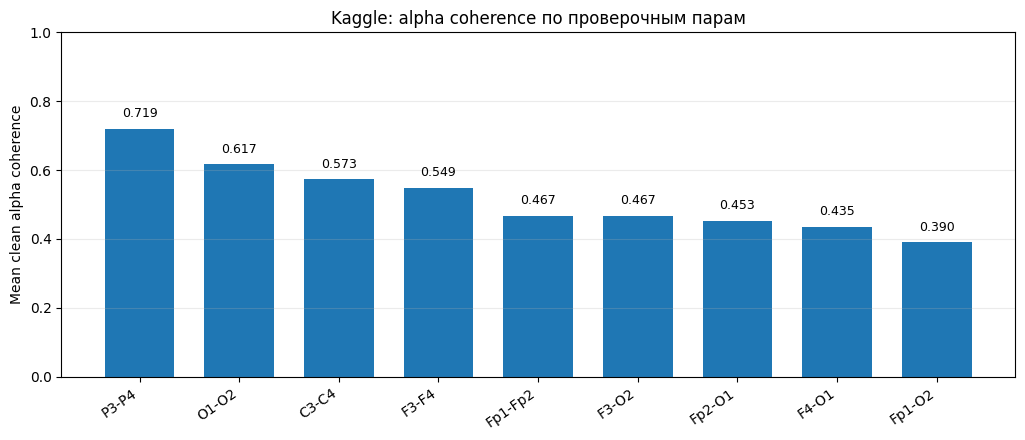

In [50]:

if KAGGLE_RESULTS is not None and not KAGGLE_VALIDATION_SUMMARY.empty:
    plot_bar(
        KAGGLE_VALIDATION_SUMMARY,
        x_col="pair",
        y_col="clean_alpha_coherence",
        title="Kaggle: alpha coherence по проверочным парам",
        ylabel="Mean clean alpha coherence",
        output_path=KAGGLE_CFG.output_dir / "kaggle_truth_alpha_coherence.png",
    )


## График Kaggle: alpha WPLI по тем же парам

WPLI менее чувствителен к нулевому фазовому сдвигу, общему источнику и референсным эффектам. Если обычная coherence высокая, а WPLI заметно ниже, связь лучше трактовать как спектральное сходство, а не как устойчивую фазовую синхронность.


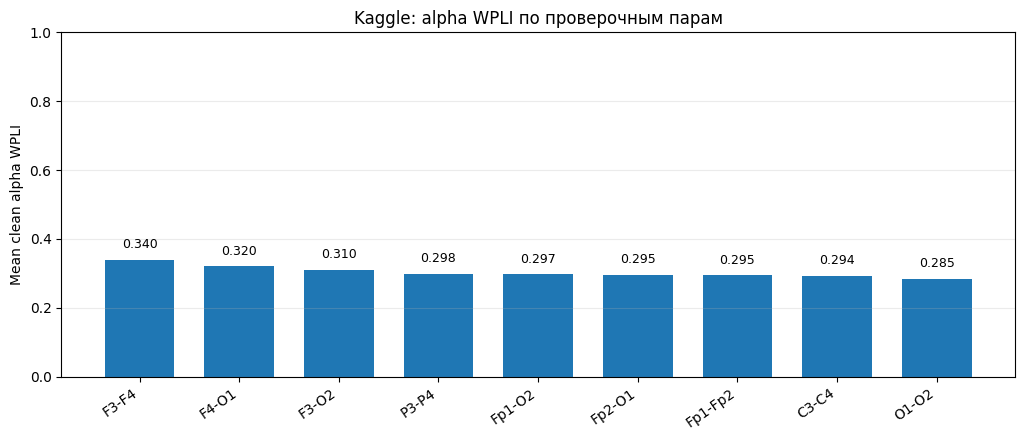

In [51]:

if KAGGLE_RESULTS is not None and not KAGGLE_VALIDATION_SUMMARY.empty:
    plot_bar(
        KAGGLE_VALIDATION_SUMMARY,
        x_col="pair",
        y_col="clean_alpha_wpli",
        title="Kaggle: alpha WPLI по проверочным парам",
        ylabel="Mean clean alpha WPLI",
        output_path=KAGGLE_CFG.output_dir / "kaggle_truth_alpha_wpli.png",
    )


## График Kaggle: профиль coherence по диапазонам

Здесь видно, в каких диапазонах каждая проверочная пара похожа сильнее. Для `O1-O2` особенно интересен alpha-диапазон, для `C3-C4` — alpha/beta.


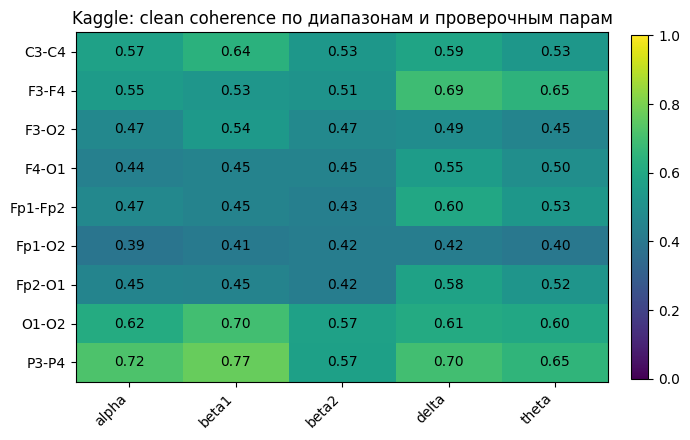

In [52]:

if KAGGLE_RESULTS is not None and not KAGGLE_VALIDATION_SUMMARY.empty:
    plot_band_metric_heatmap(
        KAGGLE_VALIDATION_SUMMARY,
        metric_suffix="coherence",
        title="Kaggle: clean coherence по диапазонам и проверочным парам",
        output_path=KAGGLE_CFG.output_dir / "kaggle_truth_coherence_by_band.png",
    )


## Проверка ожидаемых закономерностей

Ниже программа сводит пары в две группы: гомологичные и дальние контрольные. Эта проверка не доказывает физиологическую связность, но показывает, ведут ли себя рассчитанные метрики ожидаемо на внешнем ЭЭГ-наборе.


In [53]:
def make_kaggle_truth_checks(validation_summary: pd.DataFrame) -> pd.DataFrame:
    """Проверяет основные ожидаемые закономерности на Kaggle."""
    if validation_summary.empty:
        return pd.DataFrame()

    data = validation_summary.copy()
    data["is_homologous"] = data["validation_class"].isin(
        ["homologous", "homologous_occipital"]
    )
    homologous = data[data["is_homologous"]]
    distant = data[data["validation_class"] == "distant_control"]

    rows: list[dict[str, Any]] = []
    if not homologous.empty and not distant.empty:
        hom_alpha = homologous["clean_alpha_coherence"].mean()
        dist_alpha = distant["clean_alpha_coherence"].mean()
        rows.append(
            {
                "check": "Гомологичные пары против дальних контролей",
                "expected": "mean alpha coherence выше у гомологичных пар",
                "observed": f"homologous={hom_alpha:.3f}; distant={dist_alpha:.3f}",
                "result": "подтверждается" if hom_alpha > dist_alpha else "не подтверждается",
            }
        )

    if "O1-O2" in set(data["pair"]):
        ranked = data.sort_values("clean_alpha_coherence", ascending=False).reset_index(drop=True)
        o_rank = int(ranked.index[ranked["pair"] == "O1-O2"][0]) + 1
        o_value = float(data.loc[data["pair"] == "O1-O2", "clean_alpha_coherence"].iloc[0])
        rows.append(
            {
                "check": "Затылочная alpha-связь O1-O2",
                "expected": "O1-O2 находится среди верхних пар по alpha coherence",
                "observed": f"rank={o_rank}; alpha={o_value:.3f}",
                "result": "подтверждается" if o_rank <= 3 else "частично/не подтверждается",
            }
        )

    if {"clean_alpha_coherence", "clean_alpha_wpli"}.issubset(data.columns):
        coh = data["clean_alpha_coherence"].mean()
        wpli = data["clean_alpha_wpli"].mean()
        rows.append(
            {
                "check": "Coherence против WPLI",
                "expected": "обычная coherence обычно выше WPLI",
                "observed": f"coherence={coh:.3f}; WPLI={wpli:.3f}",
                "result": "подтверждается" if coh > wpli else "не подтверждается",
            }
        )

    return pd.DataFrame(rows)


if KAGGLE_RESULTS is not None and not KAGGLE_VALIDATION_SUMMARY.empty:
    KAGGLE_TRUTH_CHECKS = make_kaggle_truth_checks(KAGGLE_VALIDATION_SUMMARY)
    display(KAGGLE_TRUTH_CHECKS)


,check,expected,observed,result
0,Гомологичные пары против дальних контролей,mean alpha coherence выше у гомологичных пар,homologous=0.585; distant=0.436,подтверждается
1,Затылочная alpha-связь O1-O2,O1-O2 находится среди верхних пар по alpha coh...,rank=2; alpha=0.617,подтверждается
2,Coherence против WPLI,обычная coherence обычно выше WPLI,coherence=0.519; WPLI=0.304,подтверждается


Если ожидаемые закономерности подтверждаются хотя бы по основным пунктам, внешний контроль можно считать пройденным на базовом уровне: алгоритм не просто считает числа, а воспроизводит правдоподобную пространственную структуру ЭЭГ.


# Основной анализ файлов эксперимента: три уровня проверки

Файлы основного эксперимента берутся из папки `data`. Kaggle-файлы остаются в папке `kaggle` и не смешиваются с основными данными.

Такой порядок нужен, чтобы отделить простой вопрос «есть ли сходство сигналов?» от более строгого вопроса «похожа ли эта связь на физиологически интерпретируемую, а не на артефакт?».

In [54]:
RUN_PROJECT_ANALYSIS = True

PROJECT_DATA_DIR = Path("data")
PROJECT_CSV_GLOB = "*.csv"
PROJECT_MAX_FILES = None

# Если канал уже выглядит подозрительным, его можно исключить на отдельном уровне.
# Для новых экспериментов список можно очистить: PROJECT_EXCLUDED_CHANNELS = []
PROJECT_EXCLUDED_CHANNELS = ["POLY4"]

# Фазовые метрики работают дольше, поэтому третий уровень можно включать отдельно.
RUN_PHASE_VALIDATION_LEVEL = True

PROJECT_LEVELS = [
    {
        "name": "01_basic_minimal",
        "title": "Уровень 1: базовое сходство без жёсткой очистки",
        "description": (
            "Минимальная предобработка. Этот уровень нужен, чтобы проверить, "
            "не исчезает ли когерентность ещё до очистки артефактов."
        ),
        "run": True,
        "high_pass_hz": 0.5,
        "low_pass_hz": 45.0,
        "notch_hz": None,
        "compute_phase_metrics": False,
        "summary_prefix": "all",
        "exclude_channels": [],
    },
    {
        "name": "02_data_studio_artifact_control",
        "title": "Уровень 2: Data Studio-like предобработка и POLY-артефакты",
        "description": (
            "Фильтры близки к настройкам Data Studio. В сводке используются "
            "clean-значения, то есть окна с выраженной POLY/ЭМГ-помехой снижены "
            "или исключены из интерпретации."
        ),
        "run": True,
        "high_pass_hz": 0.53,
        "low_pass_hz": 30.0,
        "notch_hz": 50.0,
        "compute_phase_metrics": False,
        "summary_prefix": "clean",
        "exclude_channels": [],
    },
    {
        "name": "03_without_suspect_poly",
        "title": "Уровень 2b: тот же анализ без подозрительного POLY-канала",
        "description": (
            "Повтор уровня 2, но без каналов из PROJECT_EXCLUDED_CHANNELS. "
            "Так проверяется, держится ли вывод без канала, который может быть "
            "дублированным, насыщенным или аппаратно загрязнённым."
        ),
        "run": True,
        "high_pass_hz": 0.53,
        "low_pass_hz": 30.0,
        "notch_hz": 50.0,
        "compute_phase_metrics": False,
        "summary_prefix": "clean",
        "exclude_channels": PROJECT_EXCLUDED_CHANNELS,
    },
    {
        "name": "04_phase_validation",
        "title": "Уровень 3: фазовая проверка связи",
        "description": (
            "Строгая проверка через imaginary coherence, PLI и WPLI. Эти метрики "
            "не заменяют обычную coherence, но помогают понять, есть ли связь "
            "с ненулевым фазовым лагом."
        ),
        "run": RUN_PHASE_VALIDATION_LEVEL,
        "high_pass_hz": 0.53,
        "low_pass_hz": 30.0,
        "notch_hz": 50.0,
        "compute_phase_metrics": True,
        "summary_prefix": "clean",
        "exclude_channels": PROJECT_EXCLUDED_CHANNELS,
    },
]

print("Папка основного эксперимента:", PROJECT_DATA_DIR.resolve())
print("Шаблон CSV:", PROJECT_CSV_GLOB)
print("Исключаемые каналы на отдельном уровне:", PROJECT_EXCLUDED_CHANNELS)
print("Фазовый уровень включён:", RUN_PHASE_VALIDATION_LEVEL)


Папка основного эксперимента: C:\Users\chuma\Documents\диплом\программа\data
Шаблон CSV: *.csv
Исключаемые каналы на отдельном уровне: ['POLY4']
Фазовый уровень включён: True


В этой ячейке задан план основного анализа. Для финального прогона обычно оставляют все уровни, а для быстрого чернового запуска можно выключить `RUN_PHASE_VALIDATION_LEVEL`.

## Подготовка конфигураций для разных уровней

Одна и та же функция анализа используется для всех уровней. Меняются только фильтры, список исключённых каналов и набор метрик.

In [55]:
def remove_channels_from_config(
    config: AnalysisConfig,
    excluded_channels: list[str],
) -> AnalysisConfig:
    """Удаляет каналы из групп, ролей и списка POLY-каналов."""
    excluded = set(excluded_channels)
    if not excluded:
        return config

    config.groups = {
        group_name: [channel for channel in channels if channel not in excluded]
        for group_name, channels in config.groups.items()
    }
    config.groups = {
        group_name: channels
        for group_name, channels in config.groups.items()
        if channels
    }
    config.channel_roles = {
        channel: role
        for channel, role in config.channel_roles.items()
        if channel not in excluded
    }
    config.poly_channels = [
        channel for channel in config.poly_channels if channel not in excluded
    ]
    config.comparison_plan = [
        (left_group, right_group)
        for left_group, right_group in config.comparison_plan
        if left_group in config.groups and right_group in config.groups
    ]
    return config


def make_project_level_config(level: dict[str, Any]) -> AnalysisConfig:
    """Создаёт независимую конфигурацию для одного уровня анализа."""
    config = copy.deepcopy(CFG)
    config.data_dir = PROJECT_DATA_DIR
    config.csv_glob = PROJECT_CSV_GLOB
    config.output_dir = Path("analysis_results_project_split") / level["name"]
    config.output_dir.mkdir(parents=True, exist_ok=True)

    config.max_files = PROJECT_MAX_FILES
    config.high_pass_hz = level["high_pass_hz"]
    config.low_pass_hz = level["low_pass_hz"]
    config.notch_hz = level["notch_hz"]
    config.apply_filters = True
    config.compute_phase_metrics = level["compute_phase_metrics"]
    config.phase_metric_bands = ("alpha", "beta2_emg_sensitive")
    config.show_progress = True

    return remove_channels_from_config(
        config,
        excluded_channels=level.get("exclude_channels", []),
    )


def describe_project_level(level: dict[str, Any], config: AnalysisConfig) -> None:
    """Печатает короткое описание уровня перед запуском."""
    display(Markdown(f"### {level['title']}"))
    display(Markdown(level["description"]))
    print("Фильтры:", {
        "high_pass_hz": config.high_pass_hz,
        "low_pass_hz": config.low_pass_hz,
        "notch_hz": config.notch_hz,
    })
    print("Исключённые каналы:", level.get("exclude_channels", []))
    print("Группы:", config.groups)
    print("План сравнений:", config.comparison_plan)
    print("Фазовые метрики:", config.compute_phase_metrics)


Код выше создаёт отдельную конфигурацию для каждого уровня. Исходная `CFG` не перезаписывается, поэтому уровни можно запускать независимо друг от друга.

## Запуск уровней основного анализа

Каждый уровень сохраняет свои таблицы и графики в отдельную подпапку внутри `analysis_results_project_split`. Это позволяет сравнивать результаты без смешивания файлов.

In [56]:
def run_project_levels(
    levels: list[dict[str, Any]],
) -> dict[str, dict[str, Any]]:
    """Запускает выбранные уровни анализа основного эксперимента."""
    results_by_level: dict[str, dict[str, Any]] = {}

    if not RUN_PROJECT_ANALYSIS:
        print("Основной анализ выключен.")
        return results_by_level

    if not PROJECT_DATA_DIR.exists():
        print("Папка data не найдена:", PROJECT_DATA_DIR.resolve())
        return results_by_level

    for level in levels:
        if not level.get("run", False):
            print(f"Уровень пропущен: {level['name']}")
            continue

        config = make_project_level_config(level)
        describe_project_level(level, config)

        try:
            files = find_csv_files(config)
            pairs = build_channel_pairs(config)
            print("Файлов найдено:", len(files))
            print("Пар каналов:", len(pairs))

            start_time = time.perf_counter()
            results = run_analysis(config)
            elapsed = time.perf_counter() - start_time

            results_by_level[level["name"]] = {
                "level": level,
                "config": config,
                "results": results,
                "elapsed_sec": elapsed,
            }
            print(f"Уровень завершён за {elapsed:.1f} c")
        except FileNotFoundError as error:
            print("CSV не найдены для уровня", level["name"])
            print("Причина:", error)
        except RuntimeError as error:
            print("Уровень не завершён:", level["name"])
            print("Причина:", error)
        except Exception as error:  # noqa: BLE001
            print("Уровень остановлен из-за ошибки:", level["name"])
            print("Причина:", error)

    return results_by_level


PROJECT_RESULTS_BY_LEVEL = run_project_levels(PROJECT_LEVELS)
print("Запущенные уровни:", list(PROJECT_RESULTS_BY_LEVEL))


### Уровень 1: базовое сходство без жёсткой очистки

Минимальная предобработка. Этот уровень нужен, чтобы проверить, не исчезает ли когерентность ещё до очистки артефактов.

Фильтры: {'high_pass_hz': 0.5, 'low_pass_hz': 45.0, 'notch_hz': None}
Исключённые каналы: []
Группы: {'occipital_eeg': ['O1', 'O2'], 'frontal_eeg': ['Fp1', 'Fp2'], 'ears_reference_sensitive': ['A1', 'A2'], 'neck_poly_bipolar': ['POLY3', 'POLY4']}
План сравнений: [('occipital_eeg', 'neck_poly_bipolar'), ('frontal_eeg', 'neck_poly_bipolar'), ('ears_reference_sensitive', 'neck_poly_bipolar'), ('occipital_eeg', 'occipital_eeg'), ('frontal_eeg', 'frontal_eeg'), ('ears_reference_sensitive', 'ears_reference_sensitive'), ('neck_poly_bipolar', 'neck_poly_bipolar')]
Фазовые метрики: False
Файлов найдено: 55
Пар каналов: 16
Файлов к обработке: 55
Пар каналов в плане: 16
Фазовые метрики: выключены
[1/55] 251215_000006_EEG_1.csv: оконных строк 432, пар 16, 1.2 c
[2/55] 251215_000006_EEG_2.csv: оконных строк 448, пар 16, 1.2 c
[3/55] 251215_000006_EEG_3.csv: оконных строк 432, пар 16, 1.2 c
[4/55] 251215_000006_EEG_4.csv: оконных строк 416, пар 16, 1.1 c
[5/55] 251215_000006_EEG_5.csv: оконных строк

c:\Users\chuma\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\signal\_spectral_py.py:1668: RuntimeWarning: invalid value encountered in divide
  Cxy = np.abs(Pxy)**2 / Pxx / Pyy
C:\Users\chuma\AppData\Local\Temp\ipykernel_39384\3609351934.py:165: RuntimeWarning: Mean of empty slice
  results[f"{band_name}_coherence"] = float(np.nanmean(coherence_values[mask]))
C:\Users\chuma\AppData\Local\Temp\ipykernel_39384\3609351934.py:167: RuntimeWarning: Mean of empty slice
  np.nanmean(np.abs(np.imag(coherency[mask])))


[28/55] 260209_0000010_EEG.csv: оконных строк 464, пар 16, 1.1 c


...

[53/55] 260209_0000035_EEG.csv: оконных строк 252, пар 9, 1.4 c


c:\Users\chuma\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\signal\_spectral_py.py:1668: RuntimeWarning: invalid value encountered in divide
  Cxy = np.abs(Pxy)**2 / Pxx / Pyy
C:\Users\chuma\AppData\Local\Temp\ipykernel_39384\3609351934.py:165: RuntimeWarning: Mean of empty slice
  results[f"{band_name}_coherence"] = float(np.nanmean(coherence_values[mask]))
C:\Users\chuma\AppData\Local\Temp\ipykernel_39384\3609351934.py:167: RuntimeWarning: Mean of empty slice
  np.nanmean(np.abs(np.imag(coherency[mask])))


[54/55] 260209_0000036_EEG.csv: оконных строк 72, пар 9, 0.4 c


c:\Users\chuma\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\signal\_spectral_py.py:1668: RuntimeWarning: invalid value encountered in divide
  Cxy = np.abs(Pxy)**2 / Pxx / Pyy
C:\Users\chuma\AppData\Local\Temp\ipykernel_39384\3609351934.py:165: RuntimeWarning: Mean of empty slice
  results[f"{band_name}_coherence"] = float(np.nanmean(coherence_values[mask]))
C:\Users\chuma\AppData\Local\Temp\ipykernel_39384\3609351934.py:167: RuntimeWarning: Mean of empty slice
  np.nanmean(np.abs(np.imag(coherency[mask])))


[55/55] 260209_000009_EEG.csv: оконных строк 252, пар 9, 1.4 c
Анализ завершён за 68.9 c
Уровень завершён за 68.9 c
Запущенные уровни: ['01_basic_minimal', '02_data_studio_artifact_control', '03_without_suspect_poly', '04_phase_validation']


Эта ячейка выполняет расчёт. Если какой-то уровень не может быть обработан, остальные уровни не останавливаются.

## Короткие таблицы по каждому уровню

В таблицах оставлены только показатели, которые нужны для первичной интерпретации: корреляция, alpha coherence, WPLI при наличии и доля артефактных окон.

In [57]:
for level_name, bundle in PROJECT_RESULTS_BY_LEVEL.items():
    display(Markdown(f"### {bundle['level']['title']}"))
    table = bundle["results"]["compact_pairs"].copy()
    display(table.head(12))


### Уровень 1: базовое сходство без жёсткой очистки

,comparison,pair,relation_type,n_windows_clean,artifact_rate,clean_abs_time_corr_r,clean_alpha_coherence,clean_alpha_imag_coherence,clean_alpha_wpli,clean_beta2_emg_sensitive_coherence,clean_beta2_emg_sensitive_wpli
0,ears_reference_sensitive__vs__ears_reference_s...,A1-A2,EEG_EEG_CONNECTIVITY,601,0.531,0.100,0.339,0.349,NaN,0.340,NaN
1,ears_reference_sensitive__vs__neck_poly_bipolar,A1-POLY4,EEG_POLY_SPECTRAL_SIMILARITY,601,0.531,1.000,0.854,0.150,NaN,0.916,NaN
2,ears_reference_sensitive__vs__neck_poly_bipolar,A2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,601,0.531,0.043,0.343,0.342,NaN,0.339,NaN
3,ears_reference_sensitive__vs__neck_poly_bipolar,A2-POLY4,EEG_POLY_SPECTRAL_SIMILARITY,601,0.531,0.100,0.341,0.349,NaN,0.339,NaN
4,ears_reference_sensitive__vs__neck_poly_bipolar,A1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,601,0.531,0.015,0.336,0.346,NaN,0.340,NaN
5,frontal_eeg__vs__frontal_eeg,Fp1-Fp2,EEG_EEG_CONNECTIVITY,601,0.531,NaN,NaN,NaN,NaN,NaN,NaN
6,frontal_eeg__vs__neck_poly_bipolar,Fp2-POLY4,EEG_POLY_SPECTRAL_SIMILARITY,601,0.531,0.999,0.667,0.236,NaN,0.719,NaN
7,frontal_eeg__vs__neck_poly_bipolar,Fp2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,601,0.531,0.013,0.346,0.342,NaN,0.333,NaN
8,frontal_eeg__vs__neck_poly_bipolar,Fp1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,601,0.531,NaN,NaN,NaN,NaN,NaN,NaN
9,frontal_eeg__vs__neck_poly_bipolar,Fp1-POLY4,EEG_POLY_SPECTRAL_SIMILARITY,601,0.531,NaN,NaN,NaN,NaN,NaN,NaN


### Уровень 2: Data Studio-like предобработка и POLY-артефакты

,comparison,pair,relation_type,n_windows_clean,artifact_rate,clean_abs_time_corr_r,clean_alpha_coherence,clean_alpha_imag_coherence,clean_alpha_wpli,clean_beta2_emg_sensitive_coherence,clean_beta2_emg_sensitive_wpli
0,ears_reference_sensitive__vs__ears_reference_s...,A1-A2,EEG_EEG_CONNECTIVITY,501,0.609,0.055,0.338,0.349,NaN,0.338,NaN
1,ears_reference_sensitive__vs__neck_poly_bipolar,A1-POLY4,EEG_POLY_SPECTRAL_SIMILARITY,501,0.609,0.944,0.850,0.154,NaN,0.916,NaN
2,ears_reference_sensitive__vs__neck_poly_bipolar,A2-POLY4,EEG_POLY_SPECTRAL_SIMILARITY,501,0.609,0.056,0.340,0.349,NaN,0.338,NaN
3,ears_reference_sensitive__vs__neck_poly_bipolar,A2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,501,0.609,0.051,0.339,0.340,NaN,0.338,NaN
4,ears_reference_sensitive__vs__neck_poly_bipolar,A1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,501,0.609,0.097,0.333,0.344,NaN,0.340,NaN
5,frontal_eeg__vs__frontal_eeg,Fp1-Fp2,EEG_EEG_CONNECTIVITY,501,0.609,NaN,NaN,NaN,NaN,NaN,NaN
6,frontal_eeg__vs__neck_poly_bipolar,Fp2-POLY4,EEG_POLY_SPECTRAL_SIMILARITY,501,0.609,0.864,0.664,0.239,NaN,0.717,NaN
7,frontal_eeg__vs__neck_poly_bipolar,Fp2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,501,0.609,0.093,0.346,0.341,NaN,0.330,NaN
8,frontal_eeg__vs__neck_poly_bipolar,Fp1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,501,0.609,NaN,NaN,NaN,NaN,NaN,NaN
9,frontal_eeg__vs__neck_poly_bipolar,Fp1-POLY4,EEG_POLY_SPECTRAL_SIMILARITY,501,0.609,NaN,NaN,NaN,NaN,NaN,NaN


### Уровень 2b: тот же анализ без подозрительного POLY-канала

,comparison,pair,relation_type,n_windows_clean,artifact_rate,clean_abs_time_corr_r,clean_alpha_coherence,clean_alpha_imag_coherence,clean_alpha_wpli,clean_beta2_emg_sensitive_coherence,clean_beta2_emg_sensitive_wpli
0,ears_reference_sensitive__vs__ears_reference_s...,A1-A2,EEG_EEG_CONNECTIVITY,1264,0.013,0.068,0.340,0.349,NaN,0.341,NaN
1,ears_reference_sensitive__vs__neck_poly_bipolar,A2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.057,0.343,0.343,NaN,0.339,NaN
2,ears_reference_sensitive__vs__neck_poly_bipolar,A1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.106,0.337,0.346,NaN,0.341,NaN
3,frontal_eeg__vs__frontal_eeg,Fp1-Fp2,EEG_EEG_CONNECTIVITY,1264,0.013,0.480,0.451,0.339,NaN,0.439,NaN
4,frontal_eeg__vs__neck_poly_bipolar,Fp2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.118,0.339,0.345,NaN,0.338,NaN
5,frontal_eeg__vs__neck_poly_bipolar,Fp1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.109,0.337,0.346,NaN,0.339,NaN
6,occipital_eeg__vs__neck_poly_bipolar,O2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.132,0.347,0.352,NaN,0.344,NaN
7,occipital_eeg__vs__neck_poly_bipolar,O1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.104,0.338,0.343,NaN,0.337,NaN
8,occipital_eeg__vs__occipital_eeg,O1-O2,EEG_EEG_CONNECTIVITY,1264,0.013,0.108,0.339,0.344,NaN,0.337,NaN


### Уровень 3: фазовая проверка связи

,comparison,pair,relation_type,n_windows_clean,artifact_rate,clean_abs_time_corr_r,clean_alpha_coherence,clean_alpha_imag_coherence,clean_alpha_wpli,clean_beta2_emg_sensitive_coherence,clean_beta2_emg_sensitive_wpli
0,ears_reference_sensitive__vs__ears_reference_s...,A1-A2,EEG_EEG_CONNECTIVITY,1264,0.013,0.068,0.340,0.349,0.275,0.341,0.199
1,ears_reference_sensitive__vs__neck_poly_bipolar,A2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.057,0.343,0.343,0.260,0.339,0.182
2,ears_reference_sensitive__vs__neck_poly_bipolar,A1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.106,0.337,0.346,0.261,0.341,0.200
3,frontal_eeg__vs__frontal_eeg,Fp1-Fp2,EEG_EEG_CONNECTIVITY,1264,0.013,0.480,0.451,0.339,0.360,0.439,0.302
4,frontal_eeg__vs__neck_poly_bipolar,Fp2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.118,0.339,0.345,0.256,0.338,0.199
5,frontal_eeg__vs__neck_poly_bipolar,Fp1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.109,0.337,0.346,0.256,0.339,0.201
6,occipital_eeg__vs__neck_poly_bipolar,O2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.132,0.347,0.352,0.279,0.344,0.224
7,occipital_eeg__vs__neck_poly_bipolar,O1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,1264,0.013,0.104,0.338,0.343,0.261,0.337,0.202
8,occipital_eeg__vs__occipital_eeg,O1-O2,EEG_EEG_CONNECTIVITY,1264,0.013,0.108,0.339,0.344,0.267,0.337,0.210


Таблицы позволяют быстро увидеть, меняется ли картина между минимальной обработкой, стандартной обработкой и вариантом без подозрительного POLY-канала.

## Диагностика подозрительных POLY-каналов

Канал считается подозрительным не по одной паре, а если он показывает слишком высокую связь сразу с несколькими ЭЭГ-каналами. Для локального биполярного шейного канала это маловероятно физиологически.

In [58]:
def detect_suspect_poly_channels(
    pair_summary: pd.DataFrame,
    config: AnalysisConfig,
    corr_threshold: float = 0.80,
    coherence_threshold: float = 0.80,
    min_flagged_pairs: int = 2,
) -> pd.DataFrame:
    """Ищет POLY-каналы с подозрительно высокой связью с ЭЭГ-каналами."""
    if pair_summary.empty:
        return pd.DataFrame()

    poly_set = set(config.poly_channels)
    rows: list[dict[str, Any]] = []

    for _, row in pair_summary.iterrows():
        pair = str(row.get("pair", ""))
        if "-" not in pair:
            continue
        left, right = pair.split("-", maxsplit=1)
        poly_in_pair = [channel for channel in (left, right) if channel in poly_set]
        if not poly_in_pair:
            continue
        if left in poly_set and right in poly_set:
            continue

        poly_channel = poly_in_pair[0]
        corr = row.get("clean_abs_time_corr_r", np.nan)
        coherence = row.get("clean_alpha_coherence", np.nan)
        is_flagged = (
            pd.notna(corr)
            and corr >= corr_threshold
        ) or (
            pd.notna(coherence)
            and coherence >= coherence_threshold
        )

        rows.append(
            {
                "poly_channel": poly_channel,
                "pair": pair,
                "clean_abs_time_corr_r": corr,
                "clean_alpha_coherence": coherence,
                "flagged_pair": is_flagged,
            }
        )

    detail = pd.DataFrame(rows)
    if detail.empty:
        return detail

    summary = (
        detail.groupby("poly_channel", as_index=False)
        .agg(
            tested_pairs=("pair", "count"),
            flagged_pairs=("flagged_pair", "sum"),
            max_clean_corr=("clean_abs_time_corr_r", "max"),
            max_alpha_coherence=("clean_alpha_coherence", "max"),
        )
    )
    summary["suspect_channel"] = summary["flagged_pairs"] >= min_flagged_pairs
    return summary.sort_values(
        ["suspect_channel", "max_alpha_coherence"],
        ascending=[False, False],
    ).reset_index(drop=True)


for level_name, bundle in PROJECT_RESULTS_BY_LEVEL.items():
    if "artifact" not in level_name and "without_suspect" not in level_name:
        continue
    display(Markdown(f"### Диагностика: {bundle['level']['title']}"))
    suspect_table = detect_suspect_poly_channels(
        bundle["results"]["pair_summary"],
        bundle["config"],
    )
    display(suspect_table.round(3))


### Диагностика: Уровень 2: Data Studio-like предобработка и POLY-артефакты

,poly_channel,tested_pairs,flagged_pairs,max_clean_corr,max_alpha_coherence,suspect_channel
0,POLY4,6,2,0.944,0.850,True
1,POLY3,6,0,0.127,0.346,False


### Диагностика: Уровень 2b: тот же анализ без подозрительного POLY-канала

,poly_channel,tested_pairs,flagged_pairs,max_clean_corr,max_alpha_coherence,suspect_channel
0,POLY3,6,0,0.132,0.347,False


Если канал отмечен как `suspect_channel=True`, его не стоит использовать в физиологической интерпретации без проверки сырой формы сигнала и монтажа.

## Чувствительность результата к предобработке

Здесь сравнивается один и тот же показатель между уровнями. Если порядок пар почти не меняется, значит вывод не является следствием одного конкретного фильтра.

In [59]:
PROJECT_KEY_PAIRS = [
    "O1-POLY3",
    "O2-POLY3",
    "Fp1-POLY3",
    "Fp2-POLY3",
    "A1-POLY3",
    "A2-POLY3",
    "O1-POLY4",
    "A1-POLY4",
    "Fp2-POLY4",
    "O1-O2",
    "Fp1-Fp2",
    "A1-A2",
    "POLY3-POLY4",
]


def make_preprocessing_sensitivity_table(
    results_by_level: dict[str, dict[str, Any]],
    metric_name: str = "alpha_coherence",
    key_pairs: list[str] | None = None,
) -> pd.DataFrame:
    """Собирает таблицу: строки — пары, столбцы — уровни анализа."""
    rows: list[dict[str, Any]] = []

    for level_name, bundle in results_by_level.items():
        level = bundle["level"]
        summary = bundle["results"]["pair_summary"]
        prefix = level.get("summary_prefix", "clean")
        value_col = f"{prefix}_{metric_name}"
        if value_col not in summary.columns:
            continue

        for _, row in summary.iterrows():
            pair = row["pair"]
            if key_pairs is not None and pair not in key_pairs:
                continue
            rows.append(
                {
                    "pair": pair,
                    "analysis_level": level_name,
                    "value": row[value_col],
                }
            )

    data = pd.DataFrame(rows)
    if data.empty:
        return data

    table = data.pivot_table(
        index="pair",
        columns="analysis_level",
        values="value",
        aggfunc="mean",
    )
    return table.round(3)


ALPHA_SENSITIVITY = make_preprocessing_sensitivity_table(
    PROJECT_RESULTS_BY_LEVEL,
    metric_name="alpha_coherence",
    key_pairs=PROJECT_KEY_PAIRS,
)

display(ALPHA_SENSITIVITY)


analysis_level,01_basic_minimal,02_data_studio_artifact_control,03_without_suspect_poly,04_phase_validation
pair,,,,
A1-A2,0.341,0.338,0.340,0.340
A1-POLY3,0.337,0.333,0.337,0.337
A1-POLY4,0.913,0.850,NaN,NaN
A2-POLY3,0.343,0.339,0.343,0.343
Fp1-Fp2,0.451,NaN,0.451,0.451
Fp1-POLY3,0.337,NaN,0.337,0.337
Fp2-POLY3,0.340,0.346,0.339,0.339
Fp2-POLY4,0.501,0.664,NaN,NaN
O1-O2,0.338,0.333,0.339,0.339


Если значения на минимальном и стандартном уровнях близки, то фильтрация не уничтожила основную alpha coherence. Если связь исчезает только после очистки, она была связана с POLY/ЭМГ-помехой.

## График чувствительности alpha coherence

График показывает, какие пары устойчивы к изменению предобработки, а какие зависят от фильтрации или исключения подозрительного канала.

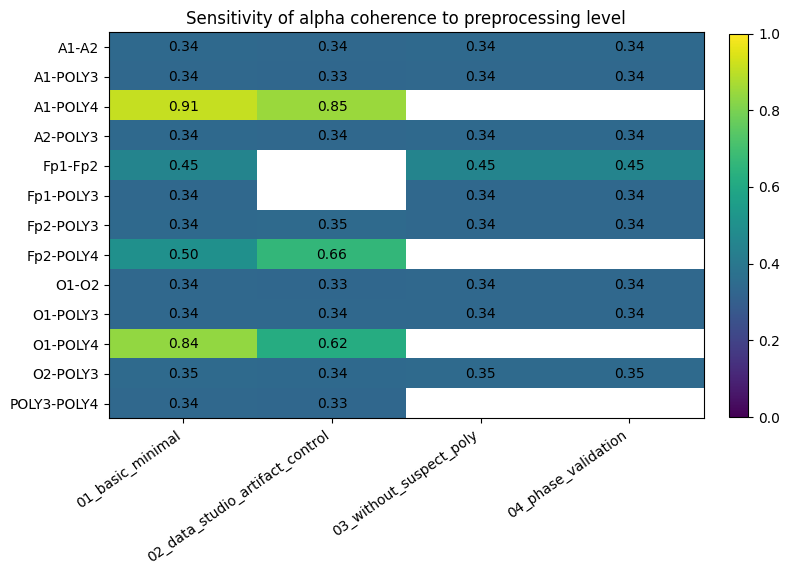

In [60]:
def plot_sensitivity_heatmap(
    sensitivity_table: pd.DataFrame,
    title: str,
    output_path: Path,
) -> None:
    """Рисует heatmap чувствительности метрики к уровню анализа."""
    if sensitivity_table.empty:
        display(Markdown("Нет данных для графика чувствительности."))
        return

    fig_width = max(7, sensitivity_table.shape[1] * 2.0)
    fig_height = max(4, sensitivity_table.shape[0] * 0.45)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    matrix = sensitivity_table.to_numpy(dtype=float)
    image = ax.imshow(matrix, aspect="auto", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(np.arange(sensitivity_table.shape[1]))
    ax.set_yticks(np.arange(sensitivity_table.shape[0]))
    ax.set_xticklabels(sensitivity_table.columns, rotation=35, ha="right")
    ax.set_yticklabels(sensitivity_table.index)

    for i in range(sensitivity_table.shape[0]):
        for j in range(sensitivity_table.shape[1]):
            value = matrix[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center")

    fig.colorbar(image, ax=ax, fraction=0.03, pad=0.04)
    _save_current_figure(output_path.parent, output_path.name)
    plt.show()


if not ALPHA_SENSITIVITY.empty:
    plot_sensitivity_heatmap(
        ALPHA_SENSITIVITY,
        title="Sensitivity of alpha coherence to preprocessing level",
        output_path=Path("analysis_results_project_split") / "alpha_coherence_sensitivity.png",
    )


На этом графике особенно важно смотреть пары с `POLY3` отдельно от пар с `POLY4`. Если `POLY4` резко выделяется, это аргумент в пользу отдельной проверки или исключения этого канала.

## Сравнение обычной coherence и WPLI на фазовом уровне

Эта часть выполняется только если включён уровень `04_phase_validation`. Высокая coherence при низком WPLI трактуется как спектральное сходство, но не как убедительная фазовая связь с ненулевым лагом.

In [61]:
def make_coherence_wpli_table(
    phase_results: dict[str, Any] | None,
) -> pd.DataFrame:
    """Готовит компактное сравнение coherence и WPLI."""
    if phase_results is None:
        return pd.DataFrame()

    summary = phase_results["results"]["pair_summary"]
    columns = [
        "comparison",
        "pair",
        "relation_type",
        "clean_alpha_coherence",
        "clean_alpha_imag_coherence",
        "clean_alpha_wpli",
        "clean_beta2_emg_sensitive_coherence",
        "clean_beta2_emg_sensitive_wpli",
    ]
    columns = [column for column in columns if column in summary.columns]
    table = summary[columns].copy()
    numeric_columns = table.select_dtypes(include=[np.number]).columns
    table[numeric_columns] = table[numeric_columns].round(3)
    return table.sort_values("clean_alpha_coherence", ascending=False)


PHASE_TABLE = make_coherence_wpli_table(
    PROJECT_RESULTS_BY_LEVEL.get("04_phase_validation")
)

if PHASE_TABLE.empty:
    display(Markdown("Фазовый уровень не запускался или не дал таблицу WPLI."))
else:
    display(PHASE_TABLE.head(15))


,comparison,pair,relation_type,clean_alpha_coherence,clean_alpha_imag_coherence,clean_alpha_wpli,clean_beta2_emg_sensitive_coherence,clean_beta2_emg_sensitive_wpli
3,frontal_eeg__vs__frontal_eeg,Fp1-Fp2,EEG_EEG_CONNECTIVITY,0.451,0.339,0.360,0.439,0.302
6,occipital_eeg__vs__neck_poly_bipolar,O2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,0.347,0.352,0.279,0.344,0.224
1,ears_reference_sensitive__vs__neck_poly_bipolar,A2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,0.343,0.343,0.260,0.339,0.182
0,ears_reference_sensitive__vs__ears_reference_s...,A1-A2,EEG_EEG_CONNECTIVITY,0.340,0.349,0.275,0.341,0.199
4,frontal_eeg__vs__neck_poly_bipolar,Fp2-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,0.339,0.345,0.256,0.338,0.199
8,occipital_eeg__vs__occipital_eeg,O1-O2,EEG_EEG_CONNECTIVITY,0.339,0.344,0.267,0.337,0.210
7,occipital_eeg__vs__neck_poly_bipolar,O1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,0.338,0.343,0.261,0.337,0.202
2,ears_reference_sensitive__vs__neck_poly_bipolar,A1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,0.337,0.346,0.261,0.341,0.200
5,frontal_eeg__vs__neck_poly_bipolar,Fp1-POLY3,EEG_POLY_SPECTRAL_SIMILARITY,0.337,0.346,0.256,0.339,0.201


Эта таблица не отменяет обычную coherence. Она показывает, остаётся ли связь заметной после перехода к более строгим фазовым метрикам.

## Итоговая интерпретация по уровням

Финальный текст строится автоматически из тех уровней, которые были запущены. Его нужно использовать как черновик, а не как замену ручной интерпретации графиков.

In [62]:
def make_kaggle_short_conclusion(validation_summary: pd.DataFrame) -> str:
    """Формирует короткий текстовый вывод по Kaggle-проверке."""
    if validation_summary.empty:
        return "Kaggle-проверка не была выполнена или не дала сводной таблицы."

    data = validation_summary.copy()
    lines = []

    if "validation_class" in data.columns:
        homologous_mask = data["validation_class"].isin(
            ["homologous", "homologous_occipital"]
        )
        distant_mask = data["validation_class"].eq("distant_control")
        homologous = data[homologous_mask]
        distant = data[distant_mask]

        if not homologous.empty and not distant.empty:
            hom_alpha = homologous["clean_alpha_coherence"].mean()
            dist_alpha = distant["clean_alpha_coherence"].mean()
            verdict = (
                "выполняется"
                if hom_alpha > dist_alpha
                else "не выполняется на этих данных"
            )
            lines.append(
                "- Проверка гомологичных пар против дальних контролей: "
                f"mean alpha coherence = {hom_alpha:.3f} против "
                f"{dist_alpha:.3f}; ожидаемая тенденция {verdict}."
            )

    if "O1-O2" in set(data["pair"]):
        ranked = data.sort_values(
            "clean_alpha_coherence",
            ascending=False,
        ).reset_index(drop=True)
        o_rank = int(ranked.index[ranked["pair"] == "O1-O2"][0]) + 1
        o_value = float(
            data.loc[data["pair"] == "O1-O2", "clean_alpha_coherence"].iloc[0]
        )
        lines.append(
            "- Пара O1-O2: "
            f"rank={o_rank} по alpha coherence, значение={o_value:.3f}. "
            "Это контроль ожидаемой затылочной альфа-согласованности."
        )

    if {"clean_alpha_coherence", "clean_alpha_wpli"}.issubset(data.columns):
        coh = data["clean_alpha_coherence"].mean()
        wpli = data["clean_alpha_wpli"].mean()
        lines.append(
            "- Сопоставление coherence и WPLI: "
            f"средняя coherence={coh:.3f}, средняя WPLI={wpli:.3f}. "
            "Если WPLI ниже, часть обычной coherence может объясняться "
            "общим источником, референсом или нулевым фазовым компонентом."
        )

    if not lines:
        return "Kaggle-проверка выполнена, но в таблице недостаточно столбцов для автоматического вывода."
    return "\n".join(lines)


In [63]:
def _best_pair_from_summary(
    pair_summary: pd.DataFrame,
    column: str,
) -> str:
    """Возвращает подпись лучшей пары по выбранному столбцу."""
    if pair_summary.empty or column not in pair_summary.columns:
        return "нет данных"
    data = pair_summary.dropna(subset=[column])
    if data.empty:
        return "нет данных"
    row = data.sort_values(column, ascending=False).iloc[0]
    return f"{row['pair']} ({row[column]:.3f})"


def make_split_analysis_conclusion(
    results_by_level: dict[str, dict[str, Any]],
) -> str:
    """Формирует короткий вывод по раздельному анализу."""
    if not results_by_level:
        return "Основной анализ не был выполнен."

    lines = []
    for level_name, bundle in results_by_level.items():
        summary = bundle["results"]["pair_summary"]
        prefix = bundle["level"].get("summary_prefix", "clean")
        coherence_col = f"{prefix}_alpha_coherence"
        corr_col = f"{prefix}_abs_time_corr_r"
        lines.append(
            f"- **{bundle['level']['title']}**: "
            f"максимальная alpha coherence — "
            f"{_best_pair_from_summary(summary, coherence_col)}; "
            f"максимальная временная корреляция — "
            f"{_best_pair_from_summary(summary, corr_col)}."
        )

    if "04_phase_validation" in results_by_level:
        phase_summary = results_by_level["04_phase_validation"]["results"]["pair_summary"]
        lines.append(
            "- На фазовом уровне обычную coherence следует сопоставлять с "
            "imaginary coherence и WPLI. Если WPLI заметно ниже coherence, "
            "результат осторожнее трактовать как спектральное сходство или "
            "общий источник, а не как прямую физиологическую связность."
        )

    if PROJECT_EXCLUDED_CHANNELS:
        lines.append(
            "- Отдельный уровень без каналов "
            f"{PROJECT_EXCLUDED_CHANNELS} показывает, какие выводы сохраняются "
            "после исключения подозрительного POLY-сигнала."
        )

    return "\n".join(lines)


display(Markdown(make_split_analysis_conclusion(PROJECT_RESULTS_BY_LEVEL)))

if KAGGLE_RESULTS is not None:
    display(Markdown("## Вывод по Kaggle-проверке\n" + make_kaggle_short_conclusion(KAGGLE_VALIDATION_SUMMARY)))

- **Уровень 1: базовое сходство без жёсткой очистки**: максимальная alpha coherence — Fp1-POLY4 (0.989); максимальная временная корреляция — Fp1-POLY4 (0.998).
- **Уровень 2: Data Studio-like предобработка и POLY-артефакты**: максимальная alpha coherence — A1-POLY4 (0.850); максимальная временная корреляция — A1-POLY4 (0.944).
- **Уровень 2b: тот же анализ без подозрительного POLY-канала**: максимальная alpha coherence — Fp1-Fp2 (0.451); максимальная временная корреляция — Fp1-Fp2 (0.480).
- **Уровень 3: фазовая проверка связи**: максимальная alpha coherence — Fp1-Fp2 (0.451); максимальная временная корреляция — Fp1-Fp2 (0.480).
- На фазовом уровне обычную coherence следует сопоставлять с imaginary coherence и WPLI. Если WPLI заметно ниже coherence, результат осторожнее трактовать как спектральное сходство или общий источник, а не как прямую физиологическую связность.
- Отдельный уровень без каналов ['POLY4'] показывает, какие выводы сохраняются после исключения подозрительного POLY-сигнала.

## Вывод по Kaggle-проверке
- Проверка гомологичных пар против дальних контролей: mean alpha coherence = 0.585 против 0.436; ожидаемая тенденция выполняется.
- Пара O1-O2: rank=2 по alpha coherence, значение=0.617. Это контроль ожидаемой затылочной альфа-согласованности.
- Сопоставление coherence и WPLI: средняя coherence=0.519, средняя WPLI=0.304. Если WPLI ниже, часть обычной coherence может объясняться общим источником, референсом или нулевым фазовым компонентом.

Смысл раздельного анализа: сначала убедиться, что связь не пропала от простой фильтрации, затем проверить влияние POLY/ЭМГ-помех, затем смотреть более строгие фазовые метрики.